# Meta Data

## Problem Description

Rossmann has provided a comprehensive dataset containing approximately one million sales records from 1,115 stores across Germany, spanning from January 1, 2013, to July 31, 2015. 

The task is to predict daily sales for these stores over a 6-week period, from August 1, 2015, to September 17, 2015.

## Train and Test Data Set


Sale specific data regarding each store for the given date, constituting of:

•	Store: a unique store ID for each store ;

•	DayOfWeek: The day of week , staring from Monday as 1;

•	Date: the date in a first day format;

•	Sales: the turnover for any given day in Euros;

•	Customers: the number of customers on a given day;

•	Open: an indicator for whether the store was open: 0 = closed, 1 = open;

•	Promo: indicates whether a store is running a promo on that day;

•	StateHoliday: indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None;

•	SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools;


## Store Data Set


The data corresponding to the stores:

•	Store: The unique store ID for each store, as the primary key;

•	StoreType: differentiates between 4 different store models: a, b, c, d;

•	Assortment: describes an assortment level: a = basic, b = extra, c = extended;

•	CompetitionDistance: distance in meters to the nearest competitor store;

•	CompetitionOpenSinceMonth: gives the month of the time the nearest competitor was opened;

•	CompetitionOpenSinceYear: gives the of the time the nearest competitor was opened;

•	Promo2: Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating;

•	Promo2SinceWeek: describes the year and calendar week when the store started participating in Promo2;

•	Promo2SinceYear: describes the year and calendar week when the store started participating in Promo2;

•	PromoInterval: describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store;


# 0. Install packages

To install the necessary packages, excute either of 0.1, 0.2, or 0.3.

## 0.1. Install the packages (versions and dependencies might not conform!)

In [1]:
# pip install numpy

In [2]:
# pip install pandas

In [3]:
# pip install matplotlib

In [4]:
# pip install seaborn

In [5]:
# pip install plotly

In [6]:
# pip install scipy

In [7]:
# pip install statsmodels

In [8]:
# pip install scikit-learn

In [9]:
# pip install xgboost

In [10]:
# pip install missingno

In [11]:
# pip install lightgbm

In [12]:
# pip install shap

In [13]:
# pip install lime

In [14]:
# pip install requests

In [15]:
# pip install --upgrade ipywidgets

In [16]:
# pip install --upgrade jupyter

In [17]:
# pip freeze > requirements.txt

 ## 0.2. Install requirements

In [18]:
# pip install -r requirements.txt

## 0.3. Create and install the UDatEMan virtual environment

Follow the given instructions:
- Run Anaconda Prompt as Administrator.
- Navigate to the pertinent directory. (cd C:\...)
- 



# 1. Import Necessary Packages

In [2]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score, mean_squared_error as mse

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

import xgboost as xgb

import shap

from lime.lime_tabular import LimeTabularExplainer

from scipy.stats.mstats import winsorize

import missingno as msno

import requests

import os

from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam


# 2. Initialise Settings

In [3]:
# To display graphs entirely in the workbook
%matplotlib inline

In [4]:
# Setting the style
style.use('tableau-colorblind10')

In [5]:
# TODO Turn on at last
# import warnings
# warnings.filterwarnings("ignore")

# 3. Load Data Sets

## 3.1. Test

In [6]:
# Load Rossmann's test data set
test_df = pd.read_csv(r"Data\test.csv", low_memory=False, )
# low_memory=False to avoid the potential mixed type inference
# View test_df data frame
test_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,4,17/09/2015,NaN,NaN,1.0,1,0,0
1,3,4,17/09/2015,NaN,NaN,1.0,1,0,0
2,7,4,17/09/2015,NaN,NaN,1.0,1,0,0
3,8,4,17/09/2015,NaN,NaN,1.0,1,0,0
4,9,4,17/09/2015,NaN,NaN,1.0,1,0,0


## 3.2. Train

In [7]:
# Load Rossmann's train data set
train_df = pd.read_csv(r"Data\train.csv", low_memory=False, )
# View train_df data frame
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,31/07/2015,5263,555,1,1,0,1
1,2,5,31/07/2015,6064,625,1,1,0,1
2,3,5,31/07/2015,8314,821,1,1,0,1
3,4,5,31/07/2015,13995,1498,1,1,0,1
4,5,5,31/07/2015,4822,559,1,1,0,1


## 3.3. Store

In [8]:
# Load Rossmann's store data set
store_df = pd.read_csv(r"Data\store.csv", low_memory=False, )
# View store_df data frame
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 3.4. ALTERNATIVELY

In [9]:
# train_df = pd.read_csv(r"Data\train.csv", low_memory=False, parse_dates=True, dayfirst=True, low_memory=False, index_col='Date', )
# test_df = pd.read_csv(r"Data\test.csv", low_memory=False, parse_dates=True, dayfirst=True, low_memory=False, index_col='Date', )
# store_df = pd.read_csv(r"Data\store.csv", low_memory=False, parse_dates=True, dayfirst=True, low_memory=False, index_col='Date', )

## parse_dates=['Date']: consider 'Date' as date format.
## parse_dates=True: pandas will try to infer the date format for each column.
## we could have first imported the data and after that convert it to date format, using:
## train.index = pd.to_datetime(train.index, dayfirst=True)
## low_memory=False: not be conservative with allocating memory, not import in chunks (it's not a large data set so we can import all of it at once)
## index_col='Date': specifying which column should be used as the index of the pandas data frame

## 3.5. Additional Data Sets

The states are important Since public holidays as well as school holidays in Germany differ from state to state. 

We can also involve the weather data (max temperature and min precipitation) based on state and date, which have impact on physical stores.

The other external data sets that could have been included in the analysis include:
- External data on World Cup dates (Special events)
- Macro indicators data
- Google trends data for keyword "ROSSMANN" for every state as of today


### 3.5.1. store-state

In [10]:
# we can use store_states.csv to map the stores to the states
store_state_df = pd.read_csv('./Data/store_states.csv')

In [11]:
store_state_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   1115 non-null   int64 
 1   State   1115 non-null   object
dtypes: int64(1), object(1)
memory usage: 17.6+ KB


In [12]:
store_state_df['State'].unique()

array(['HE', 'TH', 'NW', 'BE', 'SN', 'SH', 'HB,NI', 'BY', 'BW', 'RP',
       'ST', 'HH'], dtype=object)

In [13]:
store_state_df.duplicated().any()

False

### 3.5.2. Date-state-Weather

In [14]:
# data_urls = {
#     "Brandenburg": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3138/Brandenburg.csv",
#     "Sachsen": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3139/Sachsen.csv",
#     "Berlin": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3140/Berlin.csv",
#     "Nordrhein Westfalen": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3141/NordrheinWestfalen.csv",
#     "Schleswig Holstein": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3142/SchleswigHolstein.csv",
#     "Niedersachsen": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3143/Niedersachsen.csv",
#     "Thüringen": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3144/Th%C3%BCringen.csv",
#     "Mecklenburg Vorpommern": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3145/MecklenburgVorpommern.csv",
#     "Sachsen Anhalt": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3146/SachsenAnhalt.csv",
#     "Rheinland Pfalz": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3147/RheinlandPfalz.csv",
#     "Hamburg": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3149/Saarland.csv",
#     "Saarland": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3149/Saarland.csv",
#     "Bremen": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3150/Bremen.csv",
#     "Baden Württemberg": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3151/BadenW%C3%BCrttemberg.csv",
#     "Bayern": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3152/Bayern.csv",
#     "Hessen": "https://storage.googleapis.com/kaggle-forum-message-attachments/97075/3153/Hessen.csv"
# }


In [15]:
## It has already been done. If need to do it again, uncomment.
# # Directory to save the downloaded files
# output_dir = "datasets"

# # Create the directory if it does not exist
# os.makedirs(output_dir, exist_ok=True)

# # Function to download a file
# def download_file(url, filename):
#     response = requests.get(url)
#     response.raise_for_status()  # Check for request errors
#     with open(filename, 'wb') as file:
#         file.write(response.content)

# # Download each file
# for name, url in data_urls.items():
#     file_path = os.path.join(output_dir, f"{name}.csv")
#     print(f"Downloading {name} from {url} to {file_path}")
#     download_file(url, file_path)

# print("All files have been downloaded.")

The loading is done later, when we want to merge each data set with the others.

# 4. Data Preprocessing

There are 180 stores missing 184 days of data in the middle of the series between 1 July 2014 to 31 Dec 2014. Compared to the 1 million given data records they can be neglected, since we are relying on the characteristics of stores, not the stors id. Especially, they will have a little effect on the prediction of the test data points which are 8 months away from the last day of the missing data
We observe that for a period one of the stores has no record. After inspection, we find out that the specific store had been under refurbishment in that period.

## 4.1. Data Preparation

### 4.1.1. Missing and Incorrect Data Treatment

#### 4.1.1.1. Test

In [34]:
# Obtaining general info of the 'test_df' data frame.
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Store          41088 non-null  int64  
 1   DayOfWeek      41088 non-null  int64  
 2   Date           41088 non-null  object 
 3   Sales          0 non-null      float64
 4   Customers      0 non-null      float64
 5   Open           41077 non-null  float64
 6   Promo          41088 non-null  int64  
 7   StateHoliday   41088 non-null  object 
 8   SchoolHoliday  41088 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 2.8+ MB


In [35]:
# The complement of the above info
test_df.isnull().sum()

Store                0
DayOfWeek            0
Date                 0
Sales            41088
Customers        41088
Open                11
Promo                0
StateHoliday         0
SchoolHoliday        0
dtype: int64

In [36]:
# The number of test_df records with 0 or null 'Open'. 
test_df.loc[(test_df['Open']==0) | test_df['Open'].isnull()].count()

Store            5995
DayOfWeek        5995
Date             5995
Sales               0
Customers           0
Open             5984
Promo            5995
StateHoliday     5995
SchoolHoliday    5995
dtype: int64

In [37]:
# Obtainng the proportion of the closed stores for correcting the accuracy of the prediction.
test_closed_proportion = round(
    test_df.loc[(test_df['Open']==0) | test_df['Open'].isnull(), 'Store'].count()/ test_df['Store'].count(),
    5
    )
print('The proportion of the closed stores in the test data set is:', f'{test_closed_proportion * 100:.3f}%')

The proportion of the closed stores in the test data set is: 14.591%


In [38]:
test_df = test_df.loc[~((test_df['Open']==0) | test_df['Open'].isnull())]

In [39]:
test_df = test_df.drop(['Open'], axis=1)

In [40]:
# Dropping the 'Sales' and 'Customers' from the data frame.
test_df.drop(['Sales', 'Customers'], axis=1, inplace=True)

In [41]:
# Final check of the null values for the test data frame.
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35093 entries, 0 to 41087
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Store          35093 non-null  int64 
 1   DayOfWeek      35093 non-null  int64 
 2   Date           35093 non-null  object
 3   Promo          35093 non-null  int64 
 4   StateHoliday   35093 non-null  object
 5   SchoolHoliday  35093 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.9+ MB


#### 4.1.1.2. Train

In [42]:
# Obtaining general info of the 'train_df' data frame.
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


There are no null values in the train data set. Nevertheless, following the steps that were applied on 'test_df' for stores that were closed, we observe that in 54 additional instances, 'Sales' is 0 (within which in 52 data rows, 'Customers' is also 0).
Since the number is insignificant compared to the total number of observations, we will consider them as mistakes in inputting data, and drop them along the closed stores.

Or we can get rid of these zero sales by considring them as outliers, they will distort the shape of the sales distribution by giving a peak at the beginning since sales is non-negative.

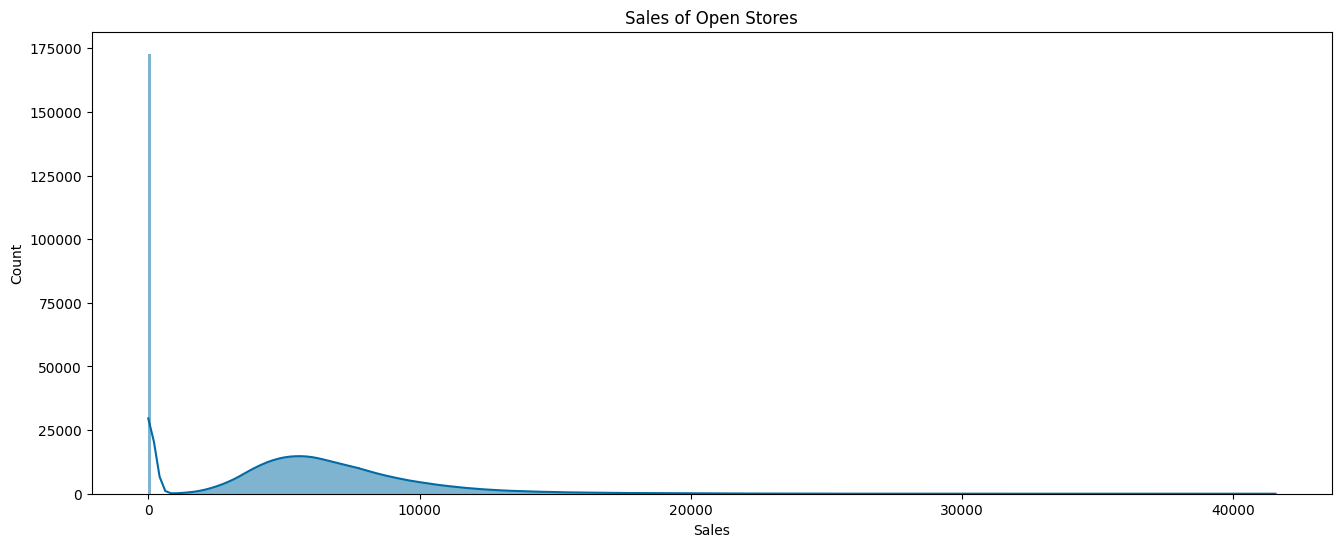

In [44]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('Sales')

# Set the label for the y-axis
ax1.set_ylabel('Count')

# Set the title for the subplot
ax1.set_title(label='Sales of Open Stores', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(train_df['Sales'], bins=400, kde=True, linewidth=0)

# Display the plot
plt.show()

In [45]:
# The number of test_df records with 0 or null 'Open'. 
train_df.loc[(train_df['Open']==0)].count()

Store            172817
DayOfWeek        172817
Date             172817
Sales            172817
Customers        172817
Open             172817
Promo            172817
StateHoliday     172817
SchoolHoliday    172817
dtype: int64

In [46]:
train_df.loc[(train_df['Open']==1) & (train_df['Sales']==0)].count()

Store            54
DayOfWeek        54
Date             54
Sales            54
Customers        54
Open             54
Promo            54
StateHoliday     54
SchoolHoliday    54
dtype: int64

In [47]:
train_df.loc[(train_df['Open']==1) & (train_df['Sales']==0) & (train_df['Customers']==0)].count()

Store            52
DayOfWeek        52
Date             52
Sales            52
Customers        52
Open             52
Promo            52
StateHoliday     52
SchoolHoliday    52
dtype: int64

In [48]:
# Obtainng the proportion of the closed stores for correcting the accuracy of the prediction.
train_closed_proportion = round(
    train_df.loc[(train_df['Open']==0) | (train_df['Sales']==0), 'Store'].count()/ train_df['Store'].count(),
    5
    )
print('The proportion of the closed stores in the test data set is:', f'{train_closed_proportion * 100:.3f}%')

The proportion of the closed stores in the test data set is: 16.995%


In [49]:
train_df = train_df.loc[~((train_df['Open']==0) | (train_df['Sales']==0))]

In [50]:
train_df = train_df.drop(['Open'], axis=1)

In [51]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Store          844338 non-null  int64 
 1   DayOfWeek      844338 non-null  int64 
 2   Date           844338 non-null  object
 3   Sales          844338 non-null  int64 
 4   Customers      844338 non-null  int64 
 5   Promo          844338 non-null  int64 
 6   StateHoliday   844338 non-null  object
 7   SchoolHoliday  844338 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 58.0+ MB


#### 4.1.1.3. Store

In [52]:
# Obtaining general info of the 'train_df' data frame.
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


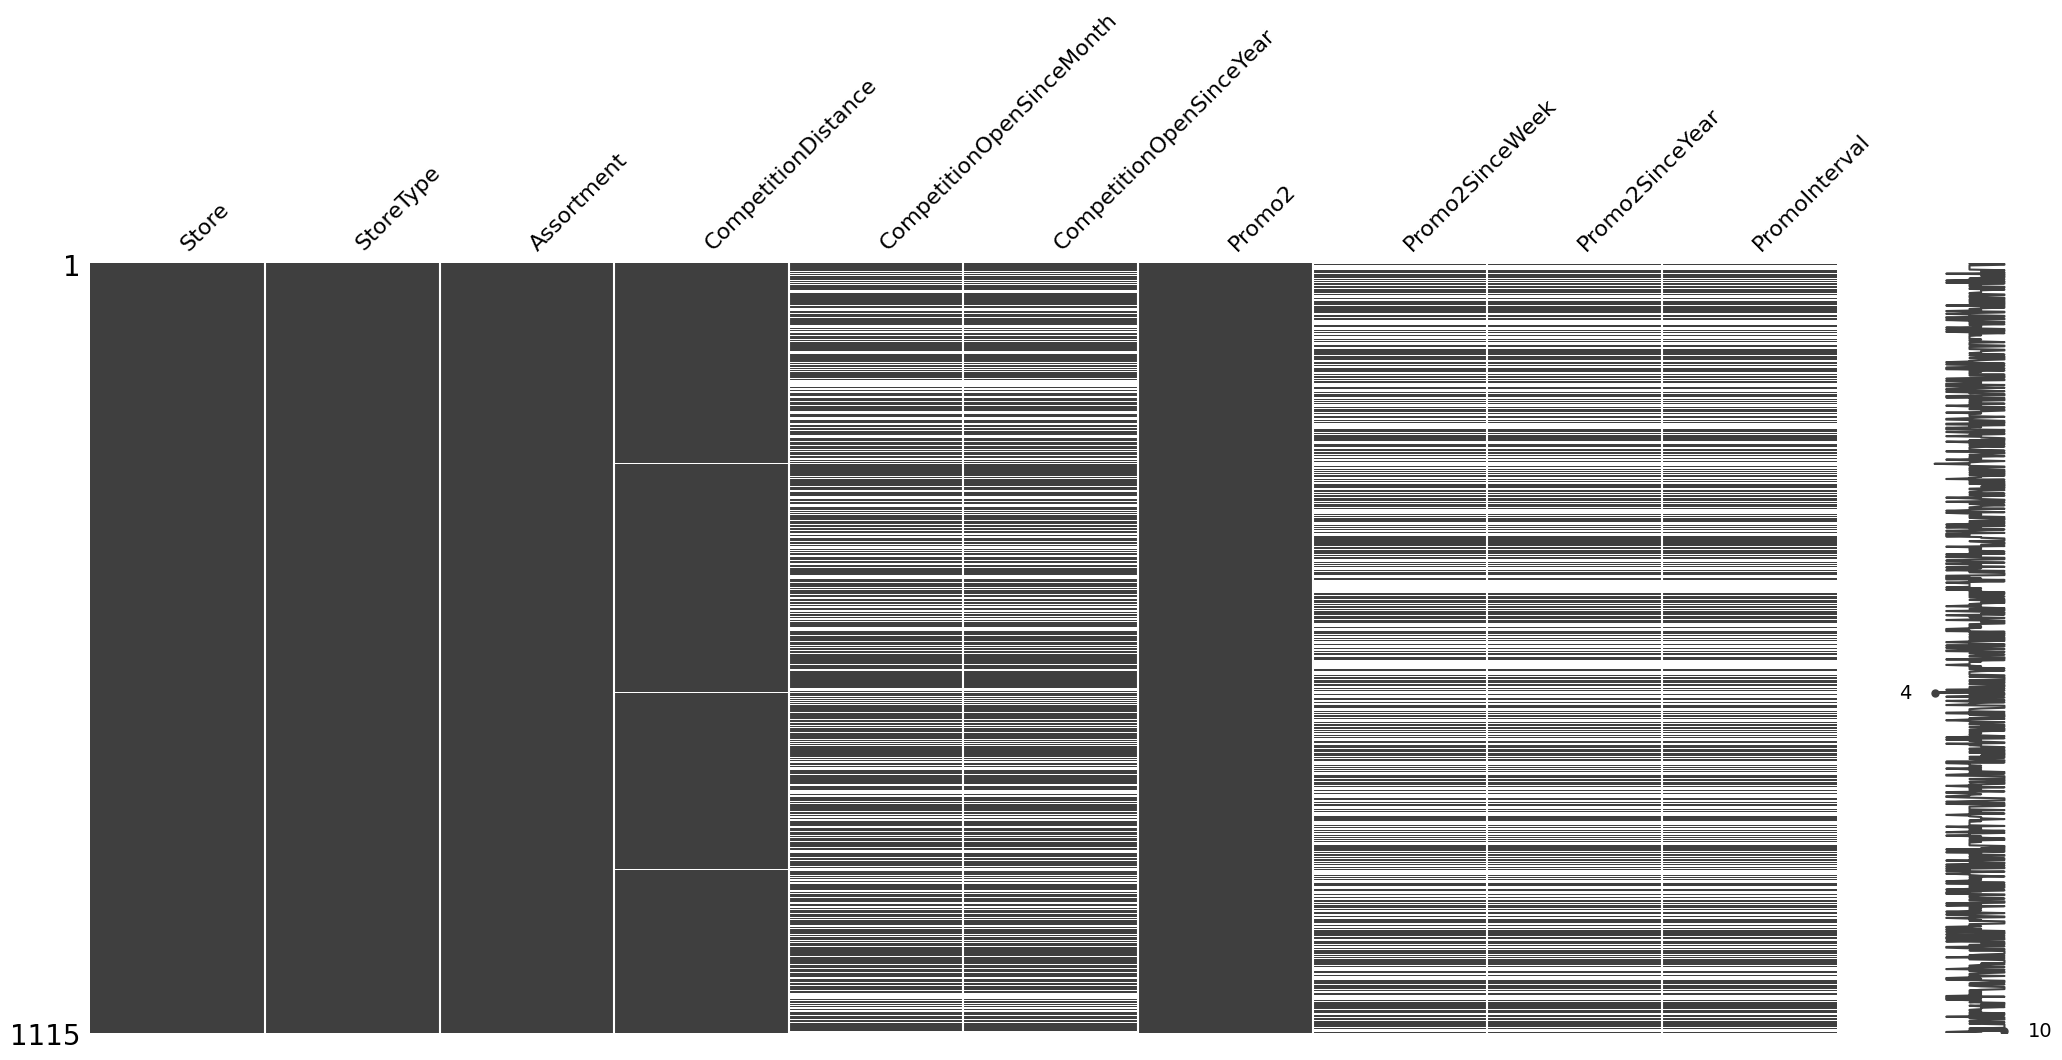

In [53]:

msno.matrix(store_df);

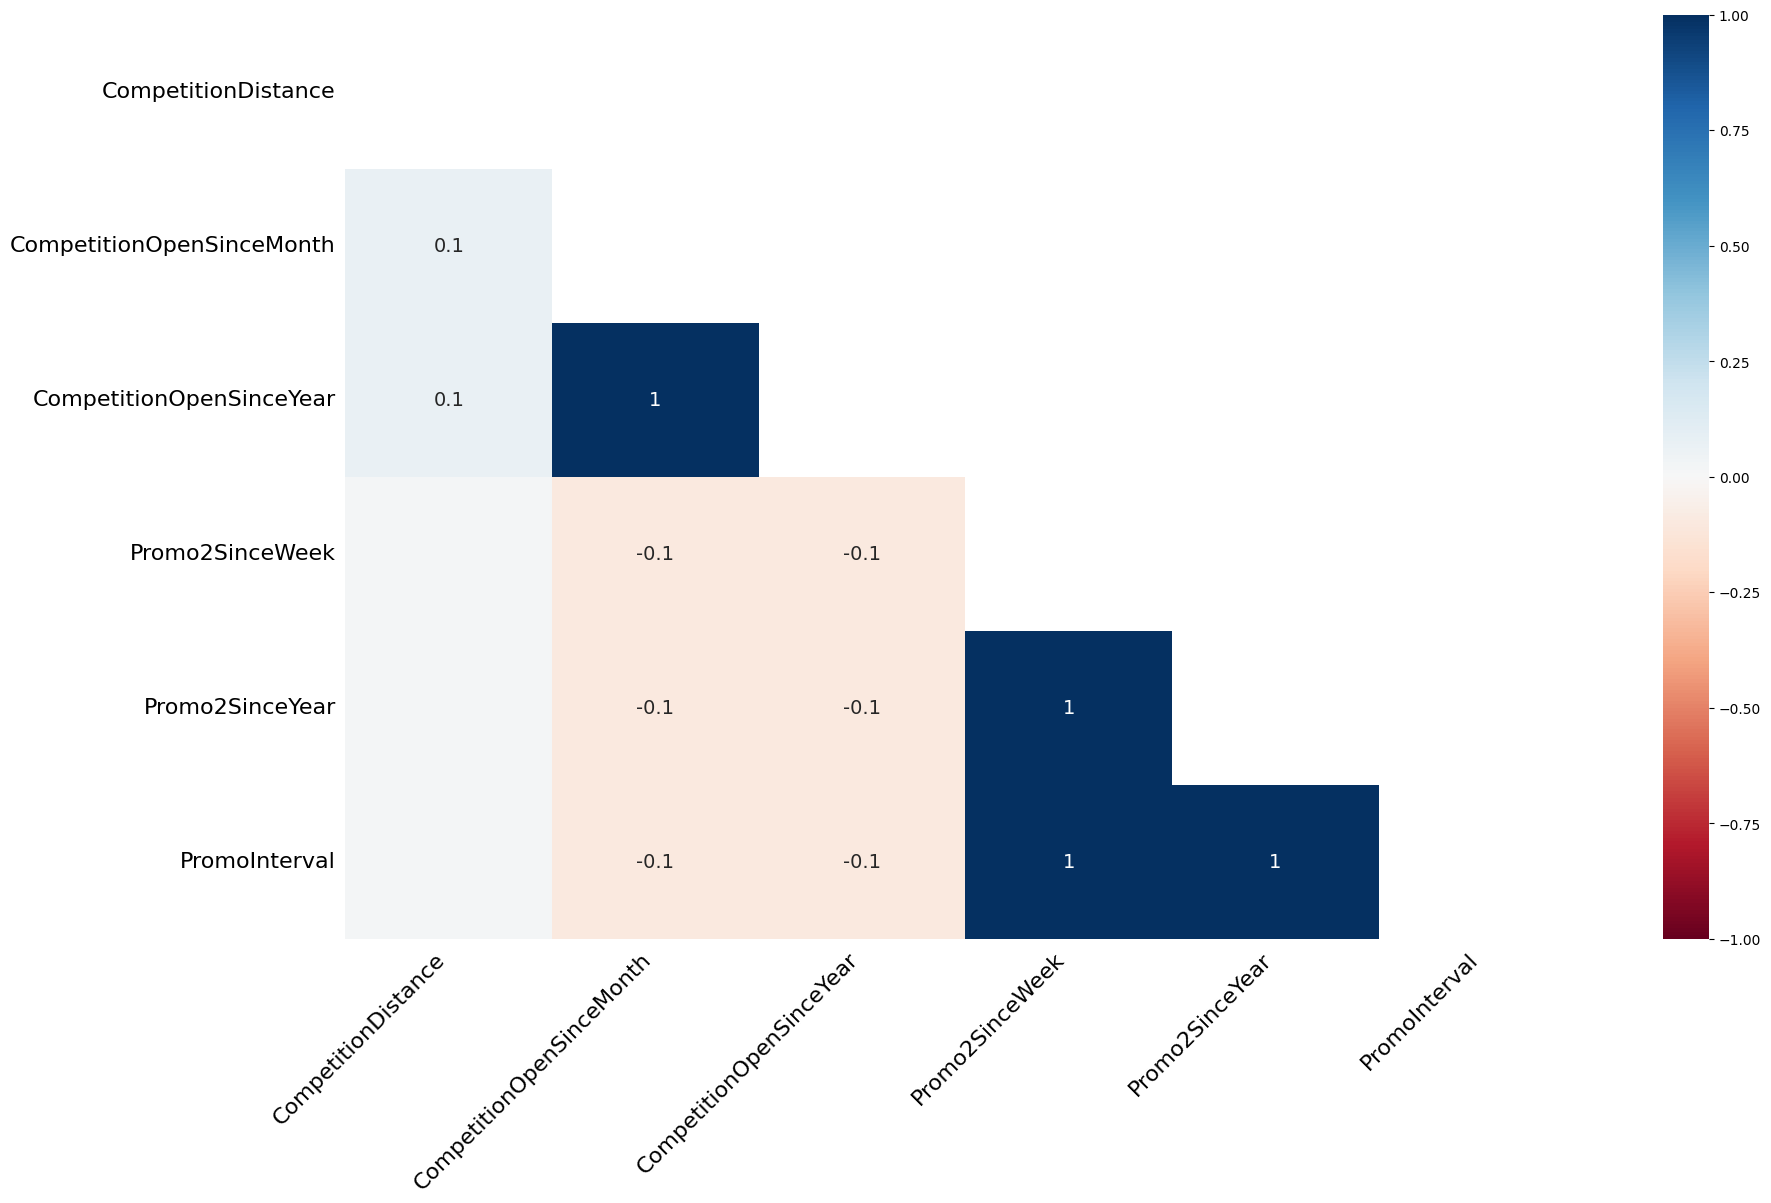

In [54]:
# Heatmap of missing data correlations
msno.heatmap(store_df);


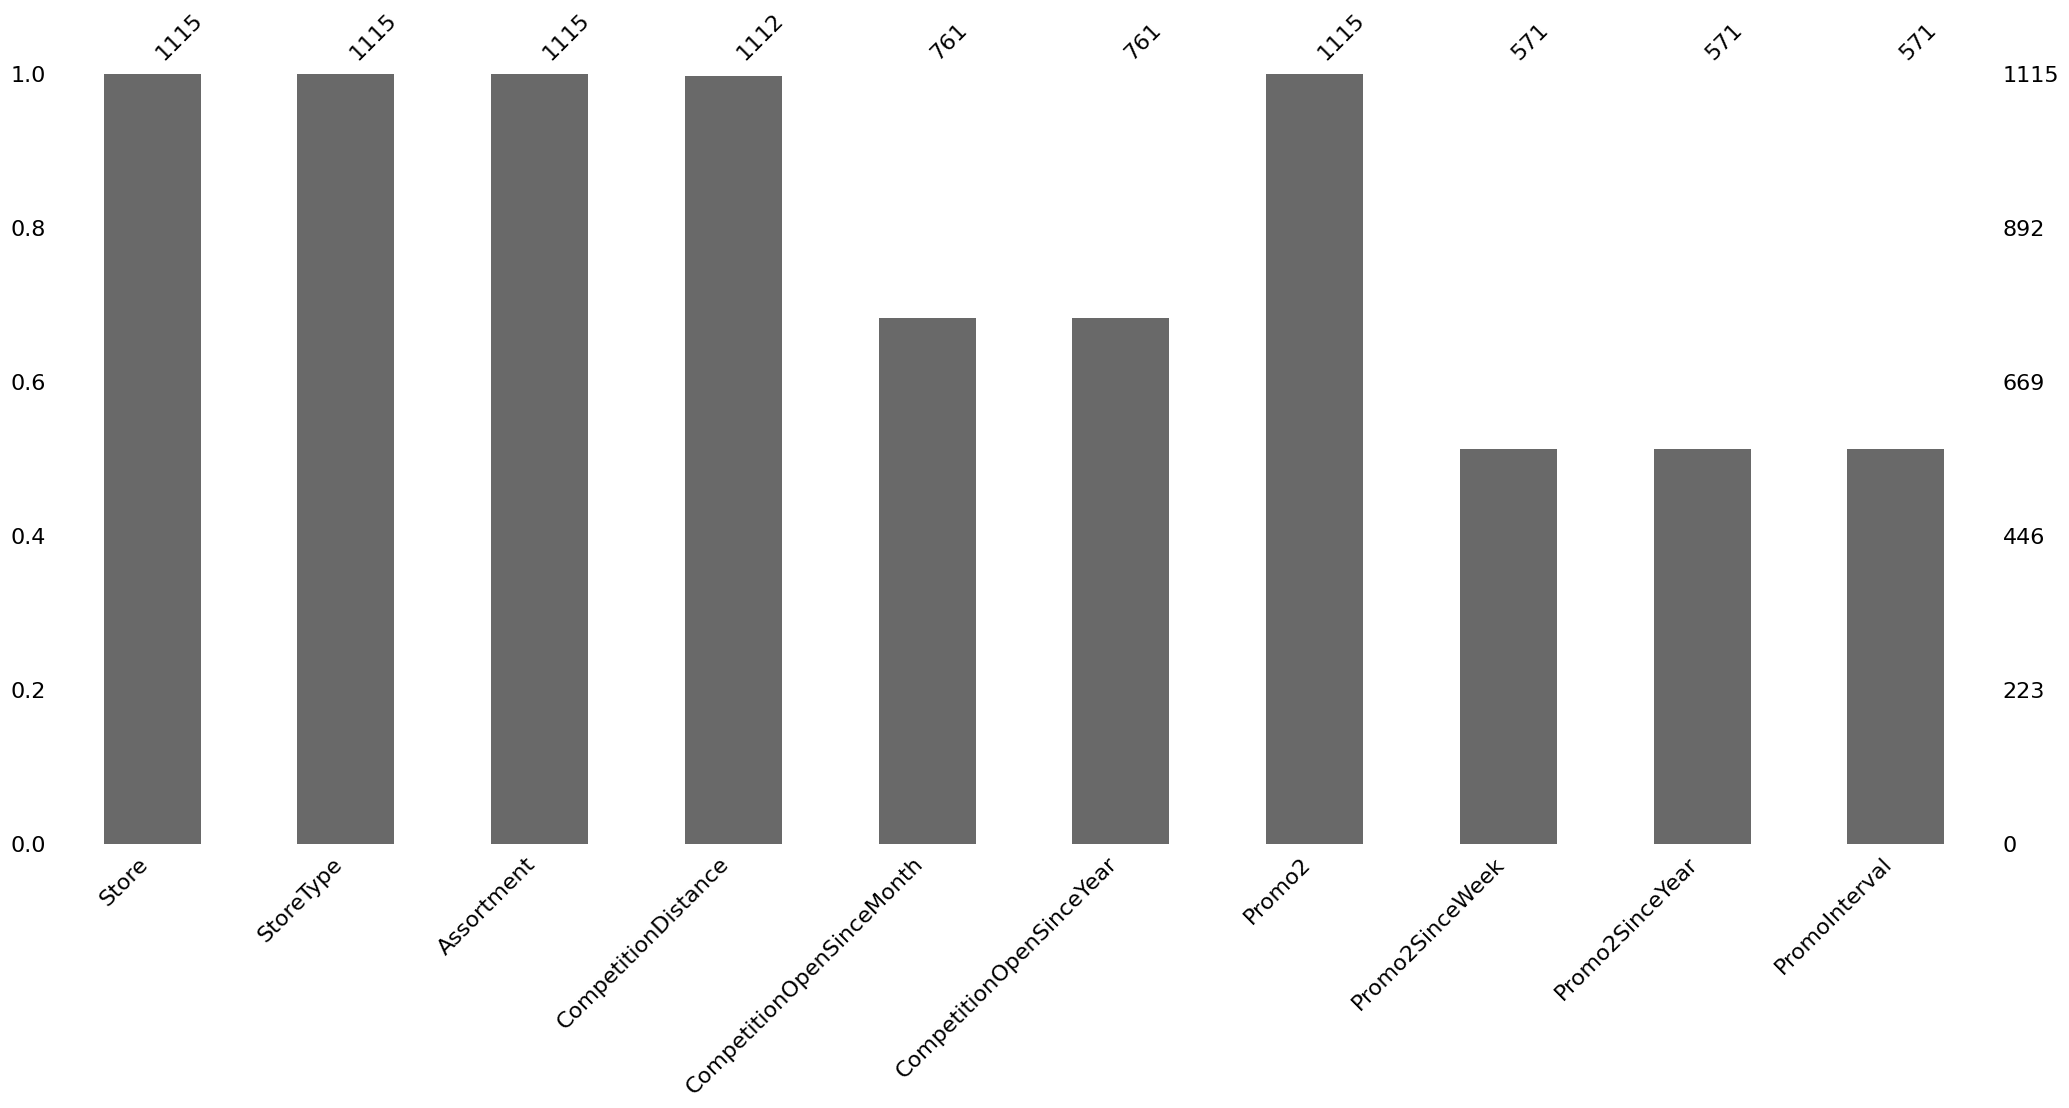

In [55]:

# Bar chart of missing data
msno.bar(store_df);

3 missing values in CompetitionDistance

and so many in CompetitionOpenSinceMonth, CompetitionOpenSinceYear, Promo2SinceWeek, Promo2SinceYear, PromoInterval

In [56]:
# Missing Completely At Random (MCAR): doesn't depend on the values of the data set 
# Treating the null values of 'CompetitionDistance', 'CompetitionOpenSinceMonth', and 'CompetitionOpenSinceYear'

# Impute CompetitionDistance with the median CompetitionDistance (median instead of mean to avoid the effect of extreme values)
store_df['CompetitionDistance'] = store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].median())

# Impute the CompetitionSinceMonth and CompetitionSinceYear with the minimum values.
store_df['CompetitionOpenSinceMonth'] = store_df['CompetitionOpenSinceMonth'].fillna(store_df['CompetitionOpenSinceMonth'].min())
store_df['CompetitionOpenSinceYear'] = store_df['CompetitionOpenSinceYear'].fillna(store_df['CompetitionOpenSinceYear'].min())

In [57]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  1115 non-null   float64
 5   CompetitionOpenSinceYear   1115 non-null   float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [58]:
store_df.loc[store_df['Promo2']==0].count()

Store                        544
StoreType                    544
Assortment                   544
CompetitionDistance          544
CompetitionOpenSinceMonth    544
CompetitionOpenSinceYear     544
Promo2                       544
Promo2SinceWeek                0
Promo2SinceYear                0
PromoInterval                  0
dtype: int64

We observe that all the 1115 - 571 = 544 missing values correspond to the cases where there was no Promo2. Therefore, we will replace the values of Promo2SinceWeek' and 'Promo2SinceYear' with -1 to indicate a systematic missing value. For PromoInterval (which should have been named Promo2Interval), we raplce the null values with 'None'. Later we will change all the 'None' values to -1.

In [59]:
# Systematic missing values
# Treating the null values of 'Promo2SinceWeek', 'Promo2SinceYear', and 'PromoInterval'

# To indicate that these are systematic missing values they are replaced with -1.
store_df['Promo2SinceWeek'] = store_df['Promo2SinceWeek'].fillna(-1)
store_df['Promo2SinceYear'] = store_df['Promo2SinceYear'].fillna(-1)
# Imputing the null cells with 'None'
store_df['PromoInterval'] = store_df['PromoInterval'].fillna('None')

In [60]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  1115 non-null   float64
 5   CompetitionOpenSinceYear   1115 non-null   float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            1115 non-null   float64
 8   Promo2SinceYear            1115 non-null   float64
 9   PromoInterval              1115 non-null   object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


### 4.1.2. Checking Compatibility of the Data Values with the Meta Data

In [61]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,35093.0,555.990055,320.142280,1.0,280.0,553.0,833.0,1115.0
DayOfWeek,35093.0,3.470977,1.722496,1.0,2.0,3.0,5.0,7.0
Promo,35093.0,0.462998,0.498636,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,35093.0,0.500698,0.500007,0.0,0.0,1.0,1.0,1.0


In [62]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,844338.0,558.421374,321.730861,1.0,280.0,558.0,837.0,1115.0
DayOfWeek,844338.0,3.520350,1.723712,1.0,2.0,3.0,5.0,7.0
Sales,844338.0,6955.959134,3103.815515,46.0,4859.0,6369.0,8360.0,41551.0
Customers,844338.0,762.777166,401.194153,8.0,519.0,676.0,893.0,7388.0
Promo,844338.0,0.446356,0.497114,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,844338.0,0.193578,0.395102,0.0,0.0,0.0,0.0,1.0


In [63]:
store_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1115.0,558.000000,322.017080,1.0,279.5,558.0,836.5,1115.0
CompetitionDistance,1115.0,5396.614350,7654.513635,20.0,720.0,2325.0,6875.0,75860.0
CompetitionOpenSinceMonth,1115.0,5.248430,3.929836,1.0,1.0,4.0,9.0,12.0
CompetitionOpenSinceYear,1115.0,1974.167713,50.866086,1900.0,1900.0,2006.0,2011.0,2015.0
Promo2,1115.0,0.512108,0.500078,0.0,0.0,1.0,1.0,1.0
Promo2SinceWeek,1115.0,11.595516,15.925223,-1.0,-1.0,1.0,22.0,50.0
Promo2SinceYear,1115.0,1029.751570,1006.538860,-1.0,-1.0,2009.0,2012.0,2015.0


Useless note!

Taking into account Promo and Promo2 are binary variables, looking at the mean and standard deviation, considering their first and second order momentums, we can assume that they have a Bernoulli distribution.

In [64]:
(0.45 * 0.55)**0.5

0.49749371855331

In [65]:
(0.51 * 0.49)**0.5

0.4998999899979995

#### 4.1.2.1. Checking the values of categorical variables

In [66]:
# Defining a function for checking the values of variables
def check_categorical_vals(df: pd.DataFrame, cat_vars: list):
    for col in df[cat_vars]:
        print(col)
        print(df[col].dtype)
        print(df[col].nunique())
        print(df[col].unique())
        print('__________________________')

In [67]:
def create_categorical_variables_list(df: pd.DataFrame, exclude_list: list=['Store', 'Date', 'Sales', 'Customers', 'CompetitionDistance']):
    return [col for col in df if col not in exclude_list]

In [68]:
# Listing the categorical variables in 'train_df' and 'test_df'
exclude_list = ['Store', 'Date', 'Sales', 'Customers', 'CompetitionDistance']
cat_vars = create_categorical_variables_list(train_df, exclude_list)

In [69]:
check_categorical_vals(train_df, cat_vars)

DayOfWeek
int64
7
[5 4 3 2 1 7 6]
__________________________
Promo
int64
2
[1 0]
__________________________
StateHoliday
object
4
['0' 'a' 'b' 'c']
__________________________
SchoolHoliday
int64
2
[1 0]
__________________________


In [70]:
# Checking the value of the categorical variables in 'test_df'
check_categorical_vals(test_df, cat_vars)

DayOfWeek
int64
7
[4 3 2 1 7 6 5]
__________________________
Promo
int64
2
[1 0]
__________________________
StateHoliday
object
2
['0' 'a']
__________________________
SchoolHoliday
int64
2
[0 1]
__________________________


We observe that StateHoliday is of String dtype, and there is no Easter or Christmas holiday in the given test interval.

In [71]:
# Listing the categorical variables in 'store_df'
cat_vars = create_categorical_variables_list(store_df, exclude_list)

In [72]:
# Checking the value of the categorical variables in 'test_df'
check_categorical_vals(store_df, cat_vars)

StoreType
object
4
['c' 'a' 'd' 'b']
__________________________
Assortment
object
3
['a' 'c' 'b']
__________________________
CompetitionOpenSinceMonth
float64
12
[ 9. 11. 12.  4. 10.  8.  1.  3.  6.  5.  2.  7.]
__________________________
CompetitionOpenSinceYear
float64
23
[2008. 2007. 2006. 2009. 2015. 2013. 2014. 2000. 2011. 1900. 2010. 2005.
 1999. 2003. 2012. 2004. 2002. 1961. 1995. 2001. 1990. 1994. 1998.]
__________________________
Promo2
int64
2
[0 1]
__________________________
Promo2SinceWeek
float64
25
[-1. 13. 14.  1. 45. 40. 26. 22.  5.  6. 10. 31. 37.  9. 39. 27. 18. 35.
 23. 48. 36. 50. 44. 49. 28.]
__________________________
Promo2SinceYear
float64
8
[-1.000e+00  2.010e+03  2.011e+03  2.012e+03  2.009e+03  2.014e+03
  2.015e+03  2.013e+03]
__________________________
PromoInterval
object
4
['None' 'Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']
__________________________


The value are compatible with the provided meta data.

### 4.1.3. Data Transformation and Feature Generation

There is no point in converting the values of categorcial variables from string to numbers, other than lower memory consumption. 
However, since we will lose expressiveness and ultimately they should (are better to) be converted to dummy variables, we won't do it.

#### 4.1.3.1 Sales

In [73]:

print(f'The skewness of Sales is {train_df['Sales'].skew():.2f}')

The skewness of Sales is 1.59


Sales is skewed to right.

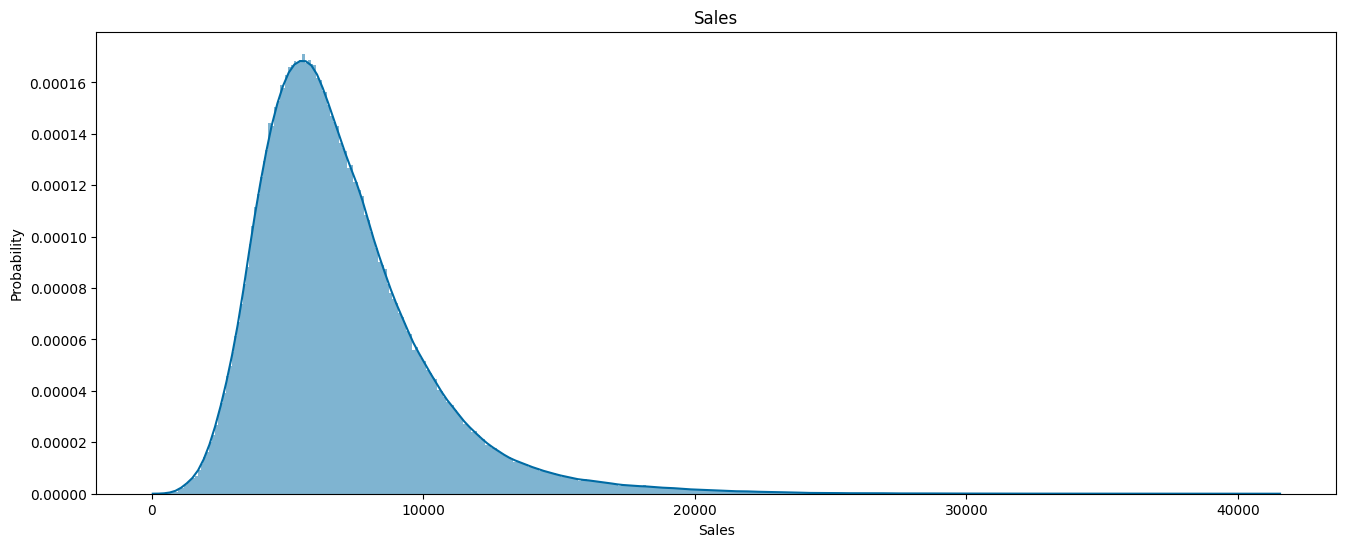

In [74]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('Sales')

# Set the label for the y-axis
ax1.set_ylabel('Probability')

# Set the title for the subplot
ax1.set_title(label='Sales', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(train_df['Sales'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()


Since it's skewed we should use log-transformation

In [75]:
train_df['log_Sales'] = np.log(train_df.Sales)

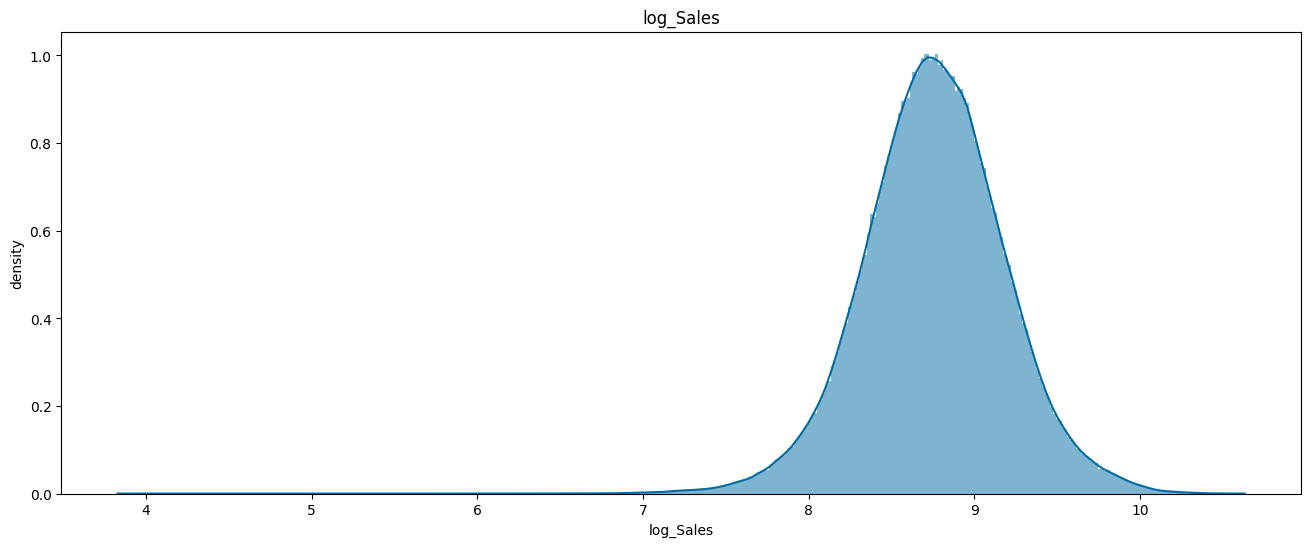

In [76]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('log_Sales')

# Set the label for the y-axis
ax1.set_ylabel('density')

# Set the title for the subplot
ax1.set_title(label='log_Sales', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(train_df['log_Sales'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()


In [77]:
print(f'The skewness of Sales is {train_df['log_Sales'].skew():.2f}')

The skewness of Sales is -0.11


It's between -0.5 and 0.5, so we can consider it as approximately symmetric.
Nevertheless, we can see there is still a thin tail on the left
If we calculate the kurtosis we see that it is less than 3 (it's paltykurtic)

In [78]:
train_df['log_Sales'].kurtosis()

0.6548797052359507

The kurtosis of the normal distribution is 3. The 'log_Sales' still doesn't have a normal distribution. 
Since we want to fit a linear regression model we should take this into consideration.

In [79]:
train_df.drop('log_Sales', axis=1, inplace=True)

##### Winsorizing removal before transforming

In [80]:
temp_train_df = train_df.copy()

In [81]:
temp_train_df['Sales'] = winsorize(temp_train_df['Sales'], limits=[0.05, 0.05])

In [82]:
temp_train_df['Sales'].skew(), temp_train_df['Sales'].kurt()

(0.6697800884197596, -0.31297378957636823)

In [83]:
temp_train_df['Customer'] = winsorize(temp_train_df['Customers'], limits=[0.05, 0.05])

In [84]:
temp_train_df['Customer'].skew(), temp_train_df['Customer'].kurt()

(0.8614283328319557, 0.05888577736525846)

In [85]:
temp_train_df['Sales'].skew(), temp_train_df['Sales'].kurt()

(0.6697800884197596, -0.31297378957636823)

In [86]:
temp_train_df['SalePerCustomer'] = temp_train_df['Sales'] / temp_train_df['Customers']

In [87]:
temp_train_df['SalePerCustomer'].skew(), temp_train_df['SalePerCustomer'].kurt()

(7.481250540144326, 978.6413934233807)

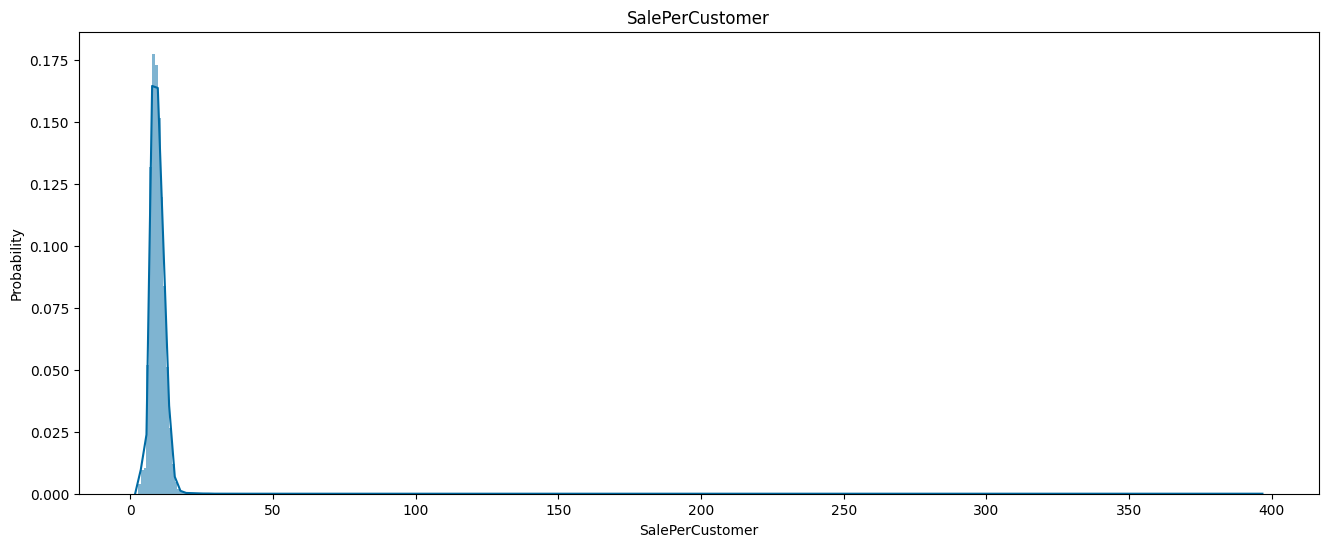

In [88]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('SalePerCustomer')

# Set the label for the y-axis
ax1.set_ylabel('Probability')

# Set the title for the subplot
ax1.set_title(label='SalePerCustomer', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(temp_train_df['SalePerCustomer'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()


That's awful! 

And considerin the peak, IQR outlier removal will make it even worse!

In [89]:
del temp_train_df

#### 4.1.3.2. Customers

In [90]:

print(f'The skewness of Customers is {train_df['Customers'].skew():.2f}')

The skewness of Customers is 2.79


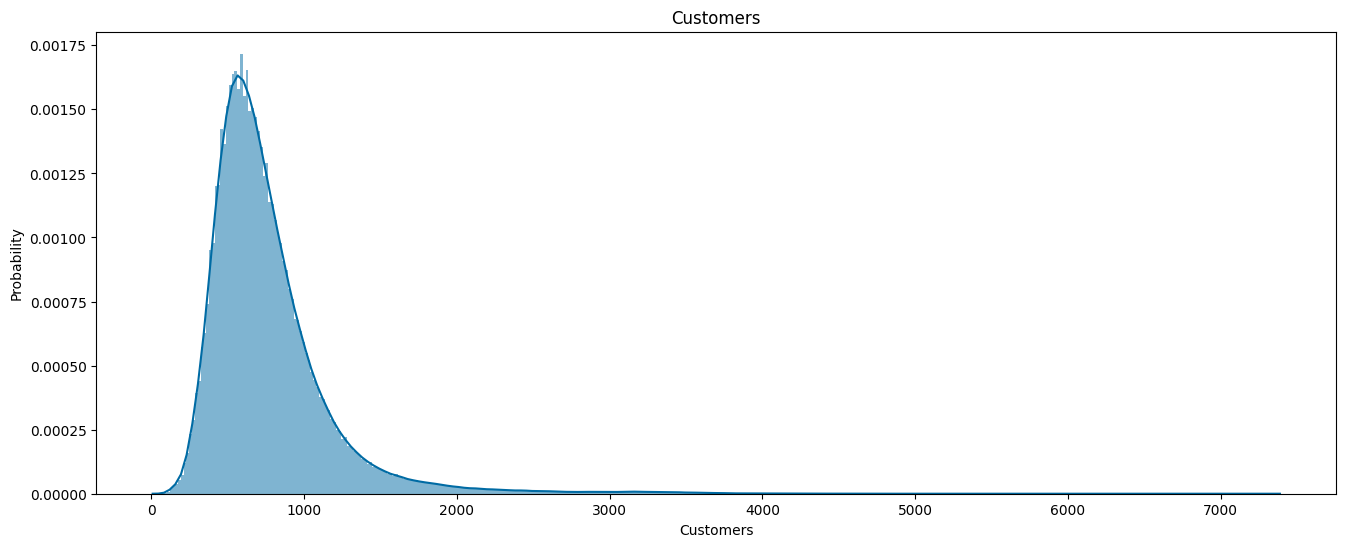

In [91]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('Customers')

# Set the label for the y-axis
ax1.set_ylabel('Probability')

# Set the title for the subplot
ax1.set_title(label='Customers', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(train_df['Customers'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()


Since it's skewed we should use log-transformation

In [92]:
train_df['log_Customers'] = np.log(train_df.Customers)

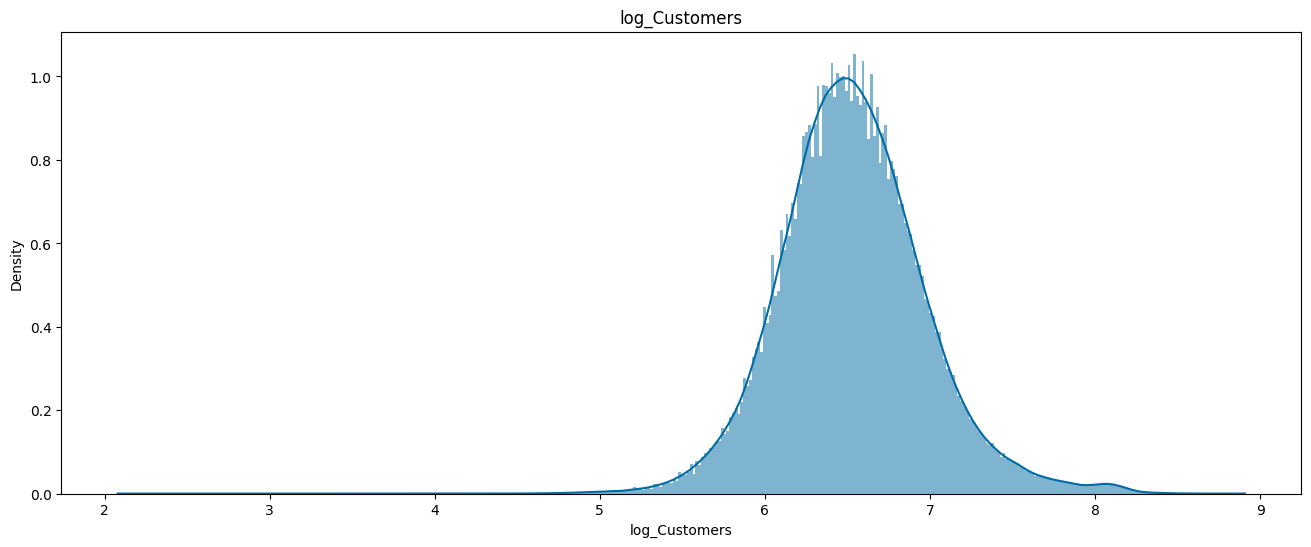

In [93]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('log_Customers')

# Set the label for the y-axis
ax1.set_ylabel('Density')

# Set the title for the subplot
ax1.set_title(label='log_Customers', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(train_df['log_Customers'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()


In [94]:
print(f'The skewness of log_Customers is {train_df['log_Customers'].skew():.2f}')

The skewness of log_Customers is 0.31


It's between -0.5 and 0.5, so we can consider it as approximately symmetric.
Nevertheless, we can see there is still a thin tail on the left
If we calculate the kurtosis we see that it is less than 3 (it's paltykurtic)

In [95]:
train_df['log_Customers'].kurtosis()

1.0689316134821158

The kurtosis of the normal distribution is 3. The 'log_Customers' still doesn't have a normal distribution. 
Since we wan to fit a linear regression model we should take this into consideration.

In [96]:
train_df.drop('log_Customers', axis=1, inplace=True)

#### 4.1.3.3. SalesPerCustomer

In [97]:
train_df['SalePerCustomer'] = train_df.Sales / train_df.Customers

In [98]:
print(f'The skewness of Sales is {train_df['SalePerCustomer'].skew():.2}')

The skewness of Sales is 0.59


In [99]:
train_df['SalePerCustomer'].kurtosis()

2.759037254095608

We observe that SalesPerCustomer has a distribution that is very close to the normal distribution. 
The advantage of considering sale per customer is that we have to deal with only one output variable. Nevertheless, neither of Sales or CUstomers can be inferred from it.

In [100]:
train_df['SalePerCustomer'].describe().T

count    844338.000000
mean          9.493641
std           2.197448
min           2.749075
25%           7.895571
50%           9.250000
75%          10.899729
max          64.957854
Name: SalePerCustomer, dtype: float64

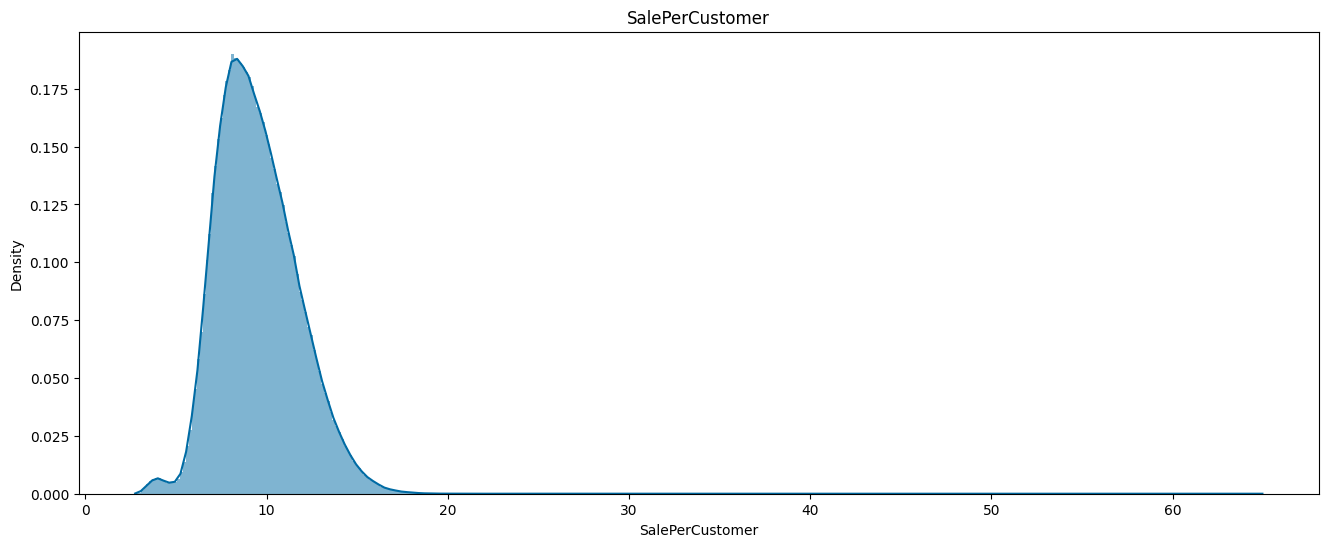

In [101]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('SalePerCustomer')

# Set the label for the y-axis
ax1.set_ylabel('Density')

# Set the title for the subplot
ax1.set_title(label='SalePerCustomer', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(train_df['SalePerCustomer'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()

##### Winsorizing after

In [102]:
temp_train_df = train_df.copy()

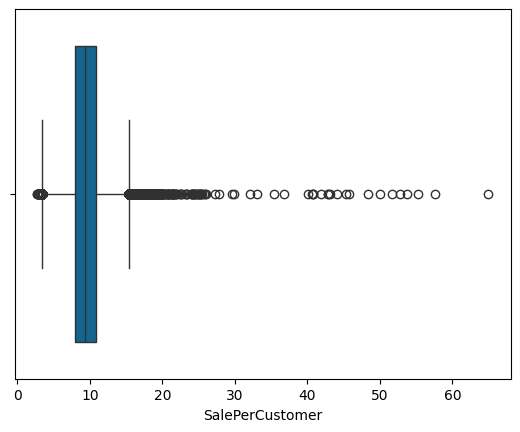

In [103]:
sns.boxplot(x='SalePerCustomer', data=temp_train_df);

In [104]:
temp_train_df['SalePerCustomer'] = winsorize(temp_train_df['SalePerCustomer'], limits=[0.05, 0.05])

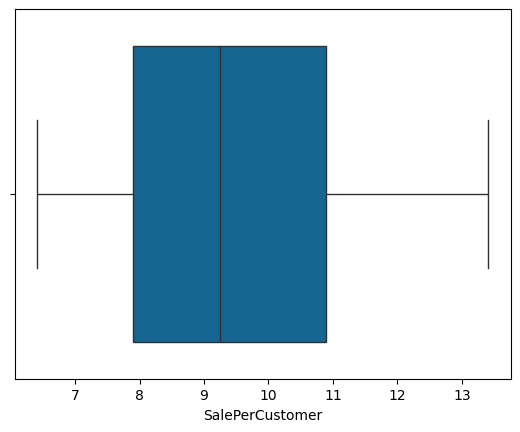

In [105]:
sns.boxplot(x='SalePerCustomer', data=temp_train_df);

In [106]:
temp_train_df['SalePerCustomer'].skew()

0.3475071427437537

In [107]:
temp_train_df['SalePerCustomer'].kurtosis()

-0.8181886356796237

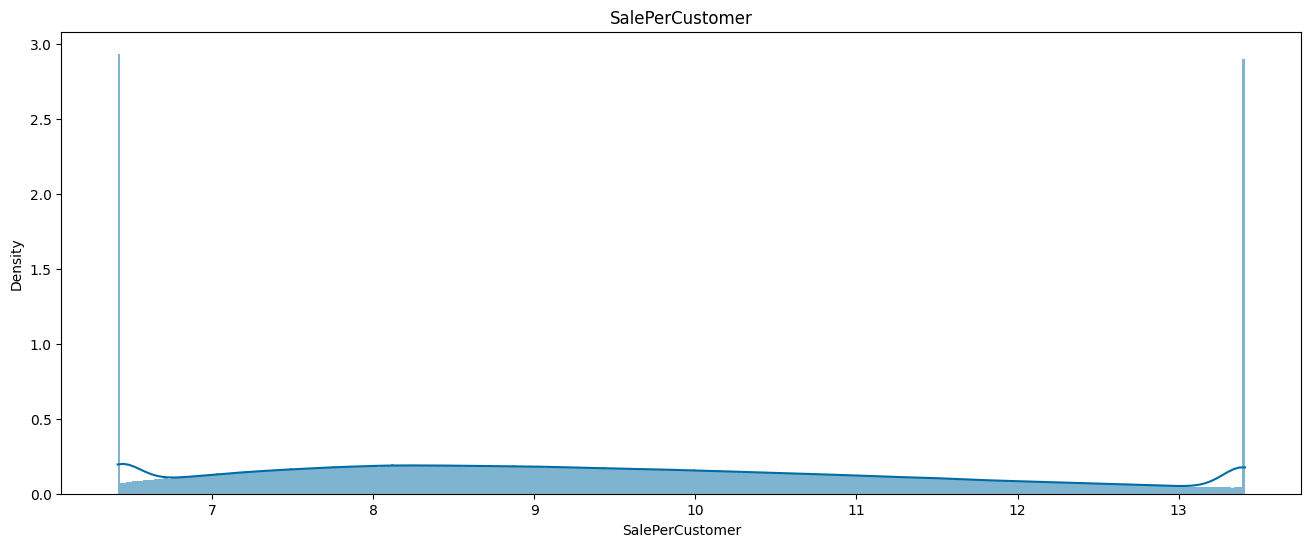

In [108]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('SalePerCustomer')

# Set the label for the y-axis
ax1.set_ylabel('Density')

# Set the title for the subplot
ax1.set_title(label='SalePerCustomer', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(temp_train_df['SalePerCustomer'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()

We shouldn't Winsorize!

##### Outlier removal using the IQR after

In [109]:
temp_train_df = train_df.copy()

In [110]:
# Calculating the 1st, 3rd, and InterQuartile Range (IQR)
Q1 = temp_train_df['SalePerCustomer'].quantile(0.25)
Q3 = temp_train_df['SalePerCustomer'].quantile(0.75)
IQR = Q3 - Q1

In [111]:
temp_train_df = temp_train_df[(temp_train_df['SalePerCustomer'] >= Q1 - 1.5*IQR) & (temp_train_df['SalePerCustomer'] <= Q3 + 1.5*IQR)]

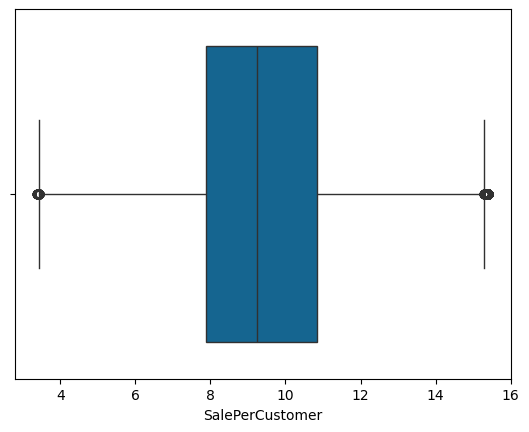

In [112]:
sns.boxplot(x='SalePerCustomer', data=temp_train_df);

In [113]:
temp_train_df['SalePerCustomer'].skew(), temp_train_df['SalePerCustomer'].kurt()

(0.32081688158880334, -0.23209609632323858)

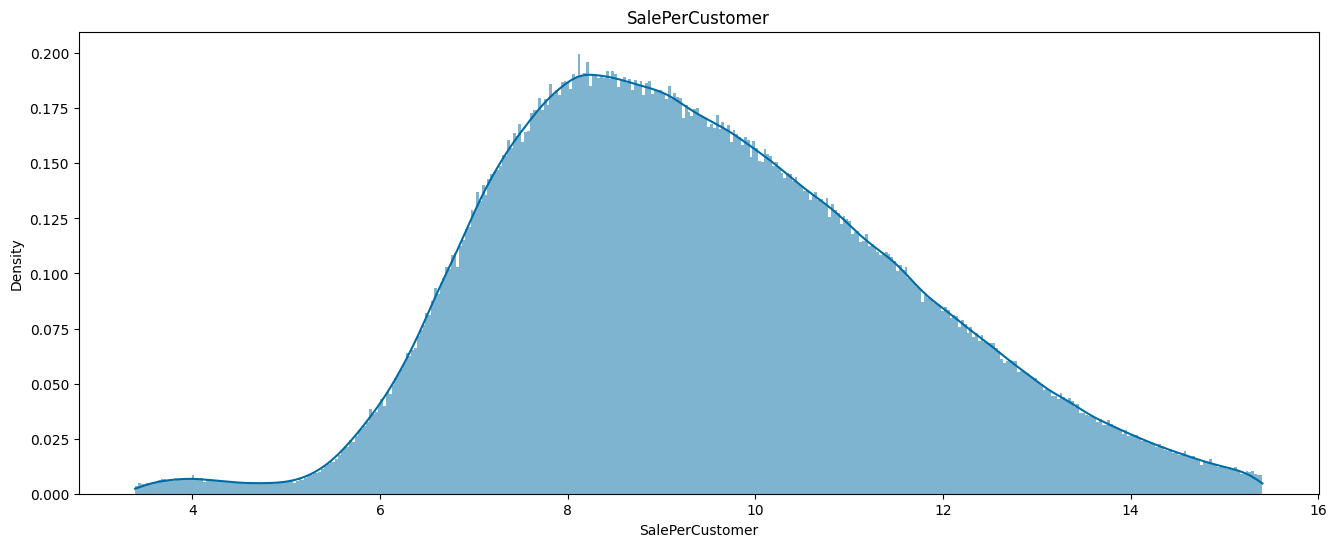

In [114]:
# Create a new figure with a specified size
fig = plt.figure(figsize=(16,6))

# Add a subplot to the figure
ax1 = fig.add_subplot()

# Set the label for the x-axis
ax1.set_xlabel('SalePerCustomer')

# Set the label for the y-axis
ax1.set_ylabel('Density')

# Set the title for the subplot
ax1.set_title(label='SalePerCustomer', loc='center')

# Create a histogram using seaborn's histplot function
sns.histplot(temp_train_df['SalePerCustomer'], bins=400, stat='density', kde=True, linewidth=0)

# Display the plot
plt.show()

The IQR outlier elimination makes compatibility of the data with the normal distribution worse and shouldn't be used.

##### 4.1.3.3.1. Checking log_SalesPerCustomer

In [115]:
train_df['log_SalePerCustomer'] = np.log(train_df.Sales / train_df.Customers)

In [116]:
print(f'The skewness of Sales is {train_df['log_SalePerCustomer'].skew()}')

The skewness of Sales is -0.2999706390855646


In [117]:
train_df['log_SalePerCustomer'].kurtosis()

0.7352351674844368

In [118]:
train_df.drop('log_SalePerCustomer', axis=1, inplace=True)

##### 4.1.3.3.2. Checking log_SalesPerlog_Customer

In [119]:
train_df['log_SalePerlog_Customer'] = np.log(train_df.Sales) / np.log(train_df.Customers)

In [120]:
print(f'The skewness of Sales is {train_df['log_SalePerlog_Customer'].skew()}')

The skewness of Sales is -0.19613083269450354


In [121]:
train_df['log_SalePerlog_Customer'].kurtosis()

0.4693621301654889

bseides being useless, how are we supposed to convert it to something related to sales and customers?!

In [122]:
train_df.drop('log_SalePerlog_Customer', axis=1, inplace=True)

In [123]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Store            844338 non-null  int64  
 1   DayOfWeek        844338 non-null  int64  
 2   Date             844338 non-null  object 
 3   Sales            844338 non-null  int64  
 4   Customers        844338 non-null  int64  
 5   Promo            844338 non-null  int64  
 6   StateHoliday     844338 non-null  object 
 7   SchoolHoliday    844338 non-null  int64  
 8   SalePerCustomer  844338 non-null  float64
dtypes: float64(1), int64(6), object(2)
memory usage: 64.4+ MB


#### 4.1.3.4. Date

In [124]:
def extract_date_elements(df: pd.DataFrame, col_name='Date'):
    '''Convert Date, and Extract Year and Month'''
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    df['Year'] = pd.DatetimeIndex(df['Date']).year
    df['Month'] = pd.DatetimeIndex(df['Date']).month

In [125]:
# Extract Date elements for 'train_df'
extract_date_elements(train_df)

In [126]:
# Extract Date elements for 'test_df'
extract_date_elements(test_df)

#### 4.1.3.5. CompetitionDistance

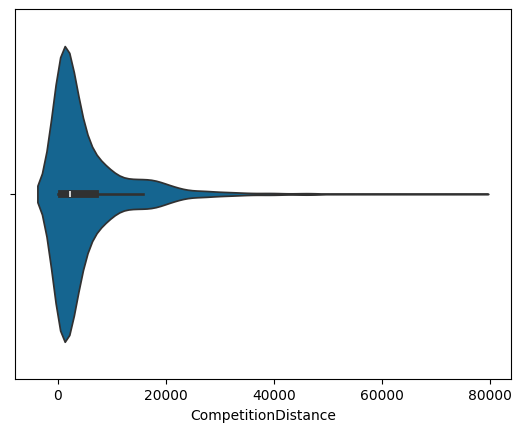

In [127]:
sns.violinplot(x=store_df['CompetitionDistance']);

In [128]:
store_df.loc[store_df['CompetitionDistance'] > 30000, 'Store'].count()

19

Winsorizing sounds a valid idea, nevertheless, before that we try the 1/sqrt(CompetitionDistance) transformation.

##### 4.1.3.5.1. Inverse Squred Root Competition Distance

In [129]:
store_df['InvSqrtCompDist'] = 1 / np.sqrt(store_df['CompetitionDistance'])

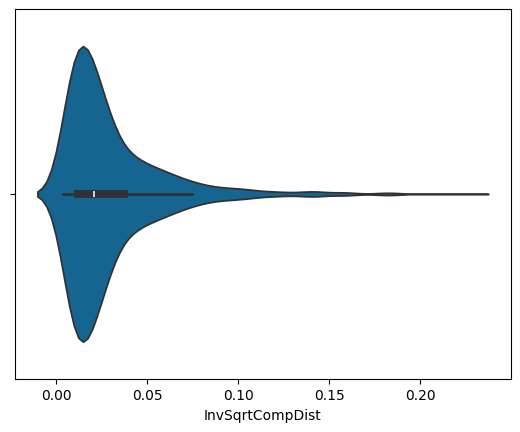

In [130]:
sns.violinplot(x=store_df['InvSqrtCompDist']);

It's not that useful, so we drop it.

In [131]:
store_df.drop('InvSqrtCompDist', axis=1, inplace=True)

##### 4.1.3.5.2. Log Inverse Squred Root Competition Distance

In [132]:
store_df['log_InvSqrtCompDist'] = np.log(1 / np.sqrt(store_df['CompetitionDistance']))

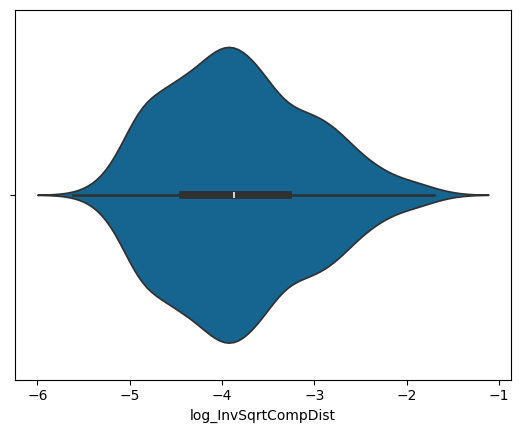

In [133]:
sns.violinplot(x=store_df['log_InvSqrtCompDist']);

In [134]:
store_df['log_InvSqrtCompDist'].skew(), store_df['log_InvSqrtCompDist'].kurt()

(0.35778091531811834, -0.4144648444769641)

It has a good symmetry. While not as critical as some other characteristics, considering symmetry and outliers can significantly improve the performance and reliability of a regression model. Addressing these aspects helps in meeting the assumptions of regression techniques and ensures more accurate and interpretable results.

##### 4.1.3.5.3. Winsorizing

By Winsorizing we are replacing the values outside of the given bound, with the extreme values. 
With the applied transformation, we don't need Windosrizing anymore.

In [135]:
# temp_store_df = store_df.copy()

# temp_store_df['CompetitionDistance'] = winsorize(temp_store_df['CompetitionDistance'], limits=[0.05, 0.05])

# sns.violinplot(x=temp_store_df['CompetitionDistance']);

# temp_store_df.loc[temp_store_df['CompetitionDistance'] > 17500, 'Store'].count()

### 4.1.4. Data Normalization and Standardization

Depending on the prediction model we should do this and in some of the in-built functions these transformations exist and are automatically applied or required to be invoked.

## 4.2. Feature Selection

Dimensionality reduction is important in avoiding the curse of dimensionality.

We do this is linear regression, to avoid multicollinearity

This is also applied automatically in regression tree (random forest, ada boost, xg boost) by using the criteria for extending the tree

## 4.3. Feature Generation

We have already generated some new features. 

This is done automatically in deep learning in the applied LSTM model.

Transforming categorical variables to the one-hot (1-out-of-k) encoding is done after integrating the data sets, since some of the categorical variables have interaction effects on each other.

Considering Promo2SinceWeek and Promo2SinceYear is meaningless. We should either transform them to categorical variables, which would make the model unnecessarily huge, or alternatively include the duration, in weeks, and drop them from the analysis. 

Since the prediction is for six weeks (the duration is low) starting from the 1st of August of 2015, we will convert the aforementioned attribute to the correpsonding duration, and name it Promo2Duration. 
If the model is intended to be used for other dayes that are farther from the current prediction period, some other way has to be sorted out. 


In [136]:
new_store_df = store_df.copy()

### 4.3.1. Promo2Duration

In [137]:
# Since some of the stores are not involved in Promo2, the Promo2Duration would be 0 for those observations.
# (new_store_df['Promo2SinceWeek'] > 0) has been used as a mask for this purpose.
new_store_df['Promo2Duration'] = \
((2015 - new_store_df['Promo2SinceYear'])*52 + (7*52 - new_store_df['Promo2SinceWeek'])) * (new_store_df['Promo2SinceWeek'] > 0)

In [138]:
new_store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,log_InvSqrtCompDist,Promo2Duration
0,1,c,a,1270.0,9.0,2008.0,0,-1.0,-1.0,None,-3.573386,0.0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",-3.172818,611.0
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",-4.778028,558.0
3,4,c,c,620.0,9.0,2009.0,0,-1.0,-1.0,None,-3.214860,0.0
4,5,a,a,29910.0,4.0,2015.0,0,-1.0,-1.0,None,-5.152974,0.0


In [139]:
new_store_df.drop(['Promo2SinceWeek', 'Promo2SinceYear'], axis=1, inplace=True)

### 4.3.2. CompetitionDuration

The same argument holds for 'CompetitionOpenSinceMonth' and 'CompetitionOpenSinceYear', but this time the duration is in months.

In [140]:
new_store_df['CompetitionDuration'] = \
((2015 - new_store_df['CompetitionOpenSinceYear'])*12 + (7*12 - new_store_df['CompetitionOpenSinceMonth']))

In [141]:
new_store_df.drop(['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'], axis=1, inplace=True)

In [142]:
new_store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,Promo2,PromoInterval,log_InvSqrtCompDist,Promo2Duration,CompetitionDuration
0,1,c,a,1270.0,0,None,-3.573386,0.0,159.0
1,2,a,a,570.0,1,"Jan,Apr,Jul,Oct",-3.172818,611.0,169.0
2,3,a,a,14130.0,1,"Jan,Apr,Jul,Oct",-4.778028,558.0,180.0
3,4,c,c,620.0,0,None,-3.214860,0.0,147.0
4,5,a,a,29910.0,0,None,-5.152974,0.0,80.0


## 4.4. Data Sets Integration

In [143]:
# We will check if the completely match when merging the 
train_df['Store'].nunique() == new_store_df['Store'].nunique()

True

### 4.4.1. store, train, state-store

In [144]:
# left join train_df with store_df on the 'store' column
total_df = pd.merge(train_df, new_store_df, on='Store', how='left').merge(store_state_df, on='Store', how='left')

### 4.4.2. Weather

In [145]:
integrated_df = total_df.copy()

In [146]:
store_state_df['State'].unique()

array(['HE', 'TH', 'NW', 'BE', 'SN', 'SH', 'HB,NI', 'BY', 'BW', 'RP',
       'ST', 'HH'], dtype=object)

In [147]:
weather_files = {
    'BE': 'Berlin.csv',
    'BW': 'Baden Württemberg.csv',
    'BY': 'Bayern.csv',
    'HB,NI': 'Niedersachsen.csv',
    'HE': 'Hessen.csv',
    'HH': 'Hamburg.csv',
    'NW': 'Nordrhein Westfalen.csv',
    'RP': 'Rheinland Pfalz.csv',
    'SH': 'Schleswig Holstein.csv',
    'SN': 'Sachsen.csv',
    'ST': 'Sachsen Anhalt.csv',
    'TH': 'Thüringen.csv'
}

In [148]:
os.chdir(r'.\datasets')

In [149]:
%pwd

'C:\\Drive D\\Python\\Rossmann\\datasets'

In [150]:
# Dictionary to hold weather dataframes
weather_dfs = {}

for state, file in weather_files.items():
    # Load the weather data
    weather_dfs[state] = pd.read_csv(file, sep=';', parse_dates=['Date'])


In [151]:
# Function to merge weather data for a given state
def merge_weather_data(df, state):
    weather_df = weather_dfs[state]
    return df.merge(weather_df[['Date', 'Max_TemperatureC', 'Min_Humidity']], on='Date', how='left')


In [152]:
# Create an empty DataFrame to hold the merged results
merged_results = pd.DataFrame()

# Apply the function to each state's data
for state in weather_files.keys():
    state_df = integrated_df[integrated_df['State'] == state]
    
    if not state_df.empty:
        merged_df = merge_weather_data(state_df, state)
        merged_results = pd.concat([merged_results, merged_df], ignore_index=True)

# Ensure that rows not matched by the weather data are included
unmatched_df = integrated_df[~integrated_df.index.isin(merged_results.index)]
final_df = pd.concat([merged_results, unmatched_df], ignore_index=True)

In [153]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Store                844338 non-null  int64         
 1   DayOfWeek            844338 non-null  int64         
 2   Date                 844338 non-null  datetime64[ns]
 3   Sales                844338 non-null  int64         
 4   Customers            844338 non-null  int64         
 5   Promo                844338 non-null  int64         
 6   StateHoliday         844338 non-null  object        
 7   SchoolHoliday        844338 non-null  int64         
 8   SalePerCustomer      844338 non-null  float64       
 9   Year                 844338 non-null  int32         
 10  Month                844338 non-null  int32         
 11  StoreType            844338 non-null  object        
 12  Assortment           844338 non-null  object        
 13  CompetitionDis

In [154]:
final_df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Promo,SchoolHoliday,SalePerCustomer,Year,Month,CompetitionDistance,Promo2,log_InvSqrtCompDist,Promo2Duration,CompetitionDuration,Max_TemperatureC,Min_Humidity
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729702912,6955.959134,762.777166,0.446356,0.193578,9.493641,2013.831945,5.845774,5450.044852,0.498670,-3.821623,254.093036,569.328269,14.431986,49.799753
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,0.000000,0.000000,2.749075,2013.000000,1.000000,20.000000,0.000000,-5.618322,0.000000,76.000000,-11.000000,4.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,0.000000,0.000000,7.895571,2013.000000,3.000000,710.000000,0.000000,-4.418187,0.000000,121.000000,8.000000,34.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,0.000000,0.000000,9.250000,2014.000000,6.000000,2325.000000,0.000000,-3.875738,0.000000,183.000000,15.000000,49.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.000000,0.000000,10.899729,2014.000000,8.000000,6880.000000,1.000000,-3.282632,506.000000,1463.000000,21.000000,65.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.000000,1.000000,64.957854,2015.000000,12.000000,75860.000000,1.000000,-1.497866,645.000000,1463.000000,38.000000,100.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.497114,0.395102,2.197448,0.777271,3.323959,7801.082007,0.499999,0.780472,261.590356,613.263871,8.531018,19.742668


In [155]:
# Free memory
del weather_dfs, weather_files

## 4.5. Categorical Encoding

### 4.5.1. Ordinal Encoding

In [156]:
# Assortment is an ordinal variable, and to reduce the complexity we will consider numbers for it
final_df.loc[final_df['Assortment']=='a', 'Assortment'] = 0
final_df.loc[final_df['Assortment']=='b', 'Assortment'] = 1
final_df.loc[final_df['Assortment']=='c', 'Assortment'] = 2

In [157]:
final_df['Assortment'] = final_df['Assortment'].astype('int8')

If we used label (integer) encoding, we don't have any control on the assigned values), whereas here the variables is ordinal.

### 4.5.2. Data Type Transformation

Data type transformation is not related to categorical encoding, however, this is the best place to convert the dtypes.

#### 4.5.2.1. Range of basic dtypes

##### 4.5.2.1.1. Integers

In [158]:
np.iinfo('int8')

iinfo(min=-128, max=127, dtype=int8)

In [159]:
np.iinfo('int16')

iinfo(min=-32768, max=32767, dtype=int16)

In [160]:
np.iinfo('int32')

iinfo(min=-2147483648, max=2147483647, dtype=int32)

In [161]:
np.iinfo('int64')

iinfo(min=-9223372036854775808, max=9223372036854775807, dtype=int64)

##### 4.5.2.1.2. Floating points

In [162]:
np.finfo('float16')

finfo(resolution=0.001, min=-6.55040e+04, max=6.55040e+04, dtype=float16)

In [163]:
np.finfo('float32')

finfo(resolution=1e-06, min=-3.4028235e+38, max=3.4028235e+38, dtype=float32)

In [164]:
np.finfo('float64')

finfo(resolution=1e-15, min=-1.7976931348623157e+308, max=1.7976931348623157e+308, dtype=float64)

#### 4.5.2.2. Features Range

Since 'Store' is just an index and has no meaningful order, we exclude it from the prediction. 

Unless a predictive model is developed for each store, it won't make sense to include 'Store' in the prediction.

In [165]:
final_df.drop('Store', axis=1, inplace=True)

#### 4.5.2.3. Dtype Conversion

In [166]:
# listing the dtype and the range of valaues for non-boolean variables.
df = final_df
for col in df.columns:
    if df[col].dtype != bool:
        print(f'{col}: f{df[col].dtype}')
        print(f'[{df[col].min()}, {df[col].max()}]')
        print('__________________________________')

DayOfWeek: fint64
[1, 7]
__________________________________
Date: fdatetime64[ns]
[2013-01-01 00:00:00, 2015-07-31 00:00:00]
__________________________________
Sales: fint64
[46, 41551]
__________________________________
Customers: fint64
[8, 7388]
__________________________________
Promo: fint64
[0, 1]
__________________________________
StateHoliday: fobject
[0, c]
__________________________________
SchoolHoliday: fint64
[0, 1]
__________________________________
SalePerCustomer: ffloat64
[2.7490747594374536, 64.95785440613027]
__________________________________
Year: fint32
[2013, 2015]
__________________________________
Month: fint32
[1, 12]
__________________________________
StoreType: fobject
[a, d]
__________________________________
Assortment: fint8
[0, 2]
__________________________________
CompetitionDistance: ffloat64
[20.0, 75860.0]
__________________________________
Promo2: fint64
[0, 1]
__________________________________
PromoInterval: fobject
[Feb,May,Aug,Nov, None]
_______

In [167]:
# We have assigned 'int8' to 'Assortment' before.
final_df = final_df.astype({
    'Promo': 'bool', 
    'Promo2': 'bool', 
    'SchoolHoliday': 'bool', 
    'Customers': 'int16', 
    'CompetitionDuration': 'int16', 
    'Promo2Duration': 'int16', 
    'Sales': 'int32', 
    'CompetitionDistance': 'int32', 
    'log_InvSqrtCompDist': 'float32', 
    'Max_TemperatureC': 'float16',
    'Min_Humidity': 'float16', 
})

In [168]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DayOfWeek            844338 non-null  int64         
 1   Date                 844338 non-null  datetime64[ns]
 2   Sales                844338 non-null  int32         
 3   Customers            844338 non-null  int16         
 4   Promo                844338 non-null  bool          
 5   StateHoliday         844338 non-null  object        
 6   SchoolHoliday        844338 non-null  bool          
 7   SalePerCustomer      844338 non-null  float64       
 8   Year                 844338 non-null  int32         
 9   Month                844338 non-null  int32         
 10  StoreType            844338 non-null  object        
 11  Assortment           844338 non-null  int8          
 12  CompetitionDistance  844338 non-null  int32         
 13  Promo2        

We observe that after the transformation the required memory requirement decreases to almost half.

### 4.5.3. One-Hot Encoding

In [169]:
# We preserve the original data frame for plotting purposes.
new_total_df = final_df.copy()

In [170]:
# SateHoliday obviously depends on the State. 
# This is also the case for SchoolHoliday, nevertheless, we ignore it to avoid the explosion of the variables ;)
new_total_df['StateHoliday_State'] = new_total_df['StateHoliday'] + '_' + new_total_df['State']

In [171]:
# We have to include the basic effects.
new_total_df = pd.get_dummies(new_total_df, columns=['StateHoliday', 'State', 'StateHoliday_State'])

Although the days of week have an order, the 1st and 5th days might have similar behaviour. The same is true for 'Month'. 

Therefore, we convert them to dummy variables. 

If we want to be more stringent, we should also include year as a categorical variable. (we pass!)

In [172]:
# Converting nominal variables to dummy variables.
new_total_df = pd.get_dummies(new_total_df, columns=['PromoInterval', 'StoreType', 'DayOfWeek', 'Month', ])

In [173]:
pd.set_option('display.max_info_columns', 200)

In [174]:
new_total_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 100 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Date                            844338 non-null  datetime64[ns]
 1   Sales                           844338 non-null  int32         
 2   Customers                       844338 non-null  int16         
 3   Promo                           844338 non-null  bool          
 4   SchoolHoliday                   844338 non-null  bool          
 5   SalePerCustomer                 844338 non-null  float64       
 6   Year                            844338 non-null  int32         
 7   Assortment                      844338 non-null  int8          
 8   CompetitionDistance             844338 non-null  int32         
 9   Promo2                          844338 non-null  bool          
 10  log_InvSqrtCompDist             844338 non-null  float3

## 4.7. Export Data to CSV

In [175]:
%pwd

'C:\\Drive D\\Python\\Rossmann\\datasets'

In [176]:
new_store_df.to_csv('store_df.csv', index=False)

In [177]:
test_df.to_csv('test_df.csv', index=False)

In [178]:
train_df.to_csv('train_df.csv', index=False)

In [179]:
total_df.to_csv('total_df.csv', index=False)

In [180]:
final_df.to_csv('final_df.csv', index=False)

In [181]:
new_total_df.to_csv('new_total_df.csv', index=False)

In [182]:
# Free some memory!
del test_df, train_df, new_store_df, store_df, total_df

# 5. Exploratory Data Analysis

In this section we visualise Sales, Customers, and SalePerCustomer against the other variables to discover the trends and identify the key factors.

## 5.1. Effect of categorical variables on sales

In [183]:
# List categorical variables
categorical_variables = [
    'DayOfWeek', 
    'Promo', 
    'StateHoliday', 
    'SchoolHoliday', 
    'StoreType', 
    'Assortment', 
    'Promo2', 
    'PromoInterval', 
    'State', 
]

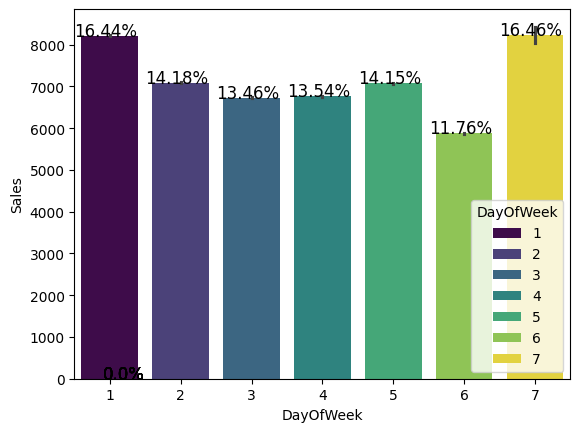

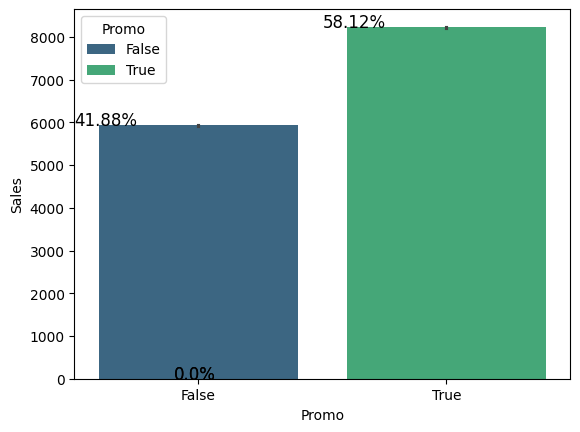

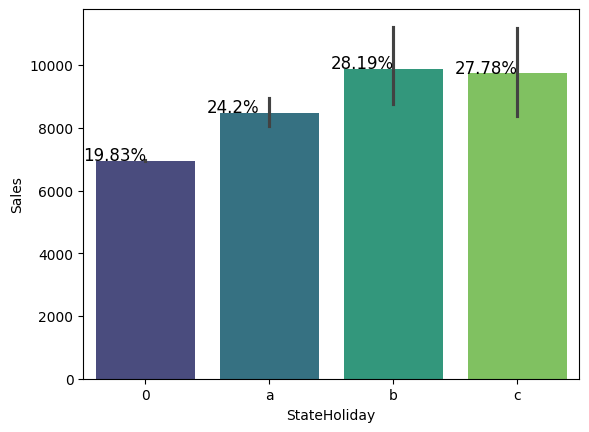

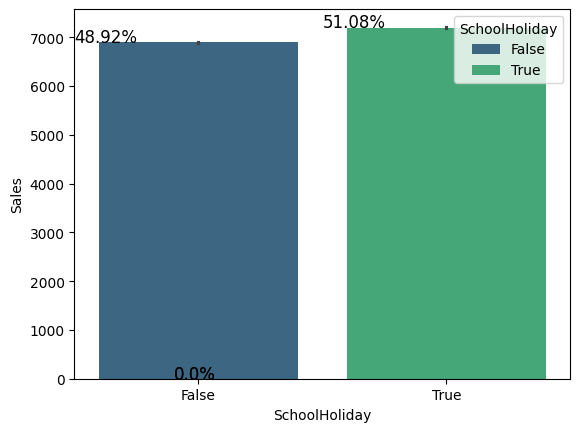

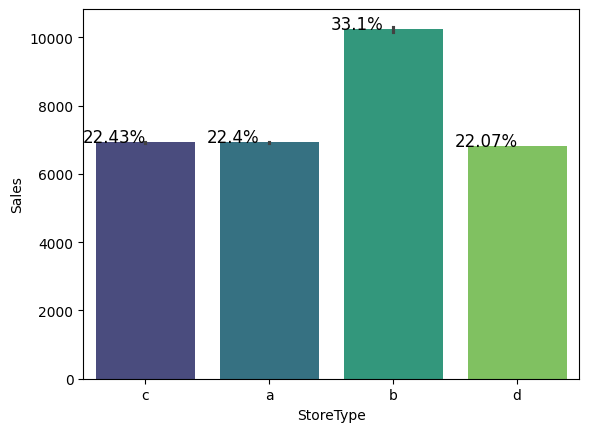

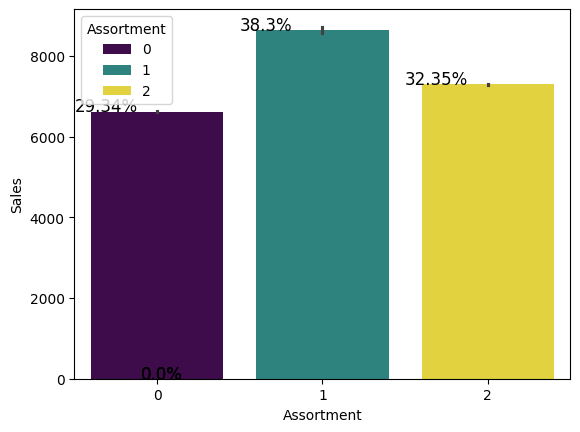

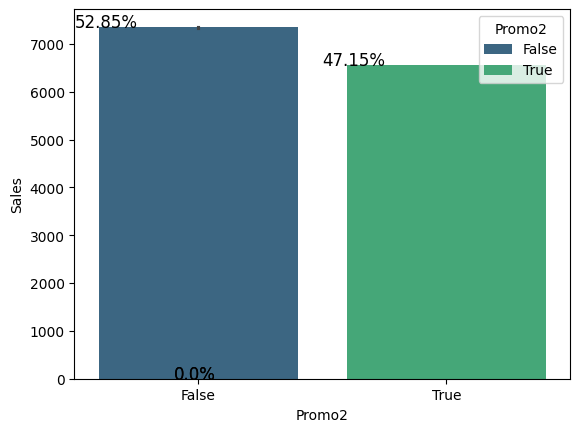

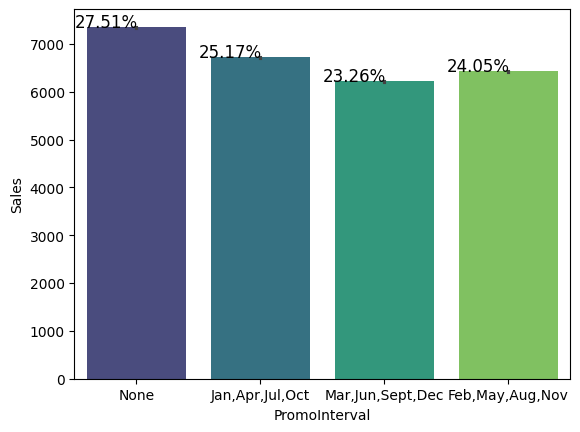

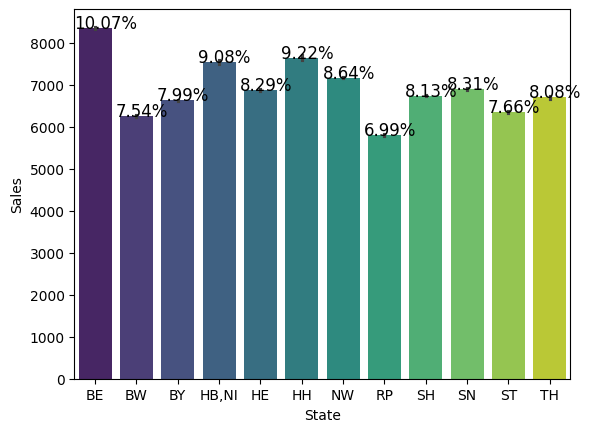

In [184]:
# total_df, for which the categorical variables were not transfomred to dummy variables is used for plotting.
for value in categorical_variables:
    ax = sns.barplot(x=final_df[value], y=final_df['Sales'], hue=final_df[value], palette='viridis')
    totals = []
    # for each patch in the barplot ax
    for i in ax.patches:
        # append height for each patch
        totals.append(i.get_height())
    
    # sum of each patch height for a plot
    total = sum(totals)

    for i in ax.patches:
        # text position and formula for percentage
        ax.text(
            i.get_x() - 0.1, i.get_height() + 0.5, str(round((i.get_height()/total)*100, 2))+'%', fontsize=12
        )
    plt.show()

The correct way to compare the values is via hypotheses tests. 

ANOVA for multiple.

Bar chart is used because it makes it easy to see the differences.
1) There were more sales on Mondays, probably because shops generally remain closed on Sundays.
2) It could be seen that the Promo leads to more sales.
3) Normally all stores, with a few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a) public holiday, b) easter holiday, c) Christmas, 0) None !!!!!! these don't coincide with the numerical values! Lowest sales are seen on state holidays, especially on Christmas.
4) More stores were open on school holidays than on state holidays, hence there were more sales compared to state holidays.
5) On average, stores of type B had the highest sales.
6) Highest average sales were seen with assortment level B, which corresponds to extra.
7) With promo2, there were slightly more sales, whihc is because many stores are participating in promo.
8) Berlin has the highest sale among the states.
9) Saturdays (corresponding to the 6th day of the week) have the lowest sales. Therefore, they are the best choice for refurbishment.


## 5.2. Effect of Competition Duration on Sales

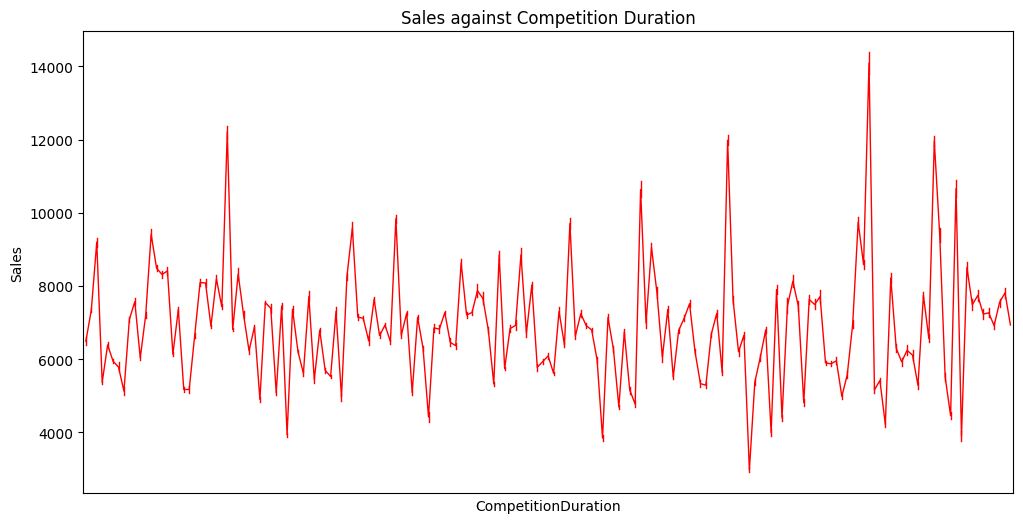

In [185]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='CompetitionDuration', y='Sales', data=final_df, color='red', markers='', linewidth=1);
plt.xticks([])
plt.title('Sales against Competition Duration')
plt.show()

As it turns out 'CompetitionDuration' doesn't contain any trend by itself. 
Maybe it does if we include other inetrmediary or moderator variables (conisideirng the causal structure).

So individually, with the increase or decrease of competition duration, we can't expect any consistent change in sales.

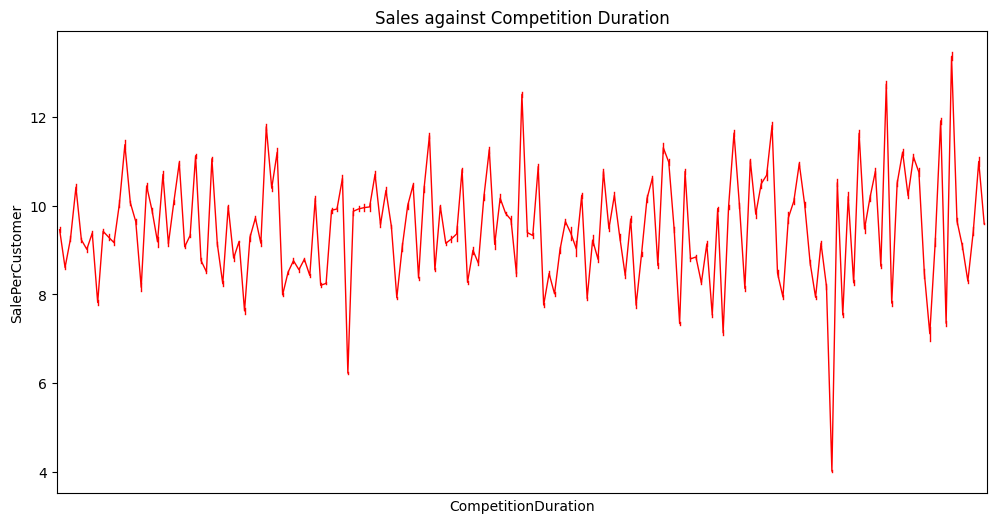

In [186]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='CompetitionDuration', y='SalePerCustomer', data=final_df, color='red', markers='', linewidth=1);
plt.xticks([])
plt.title('Sales against Competition Duration')
plt.show()

## 5.3. Share of Different Store Types in Sales, Customers, CustomerPerSale, and number of stores

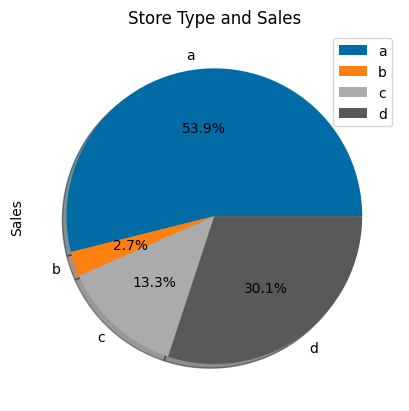

In [187]:
final_df.groupby('StoreType')['Sales'].sum().plot.pie(title='Store Type and Sales', legend=True, autopct='%1.1f%%', shadow=True)
plt.show()

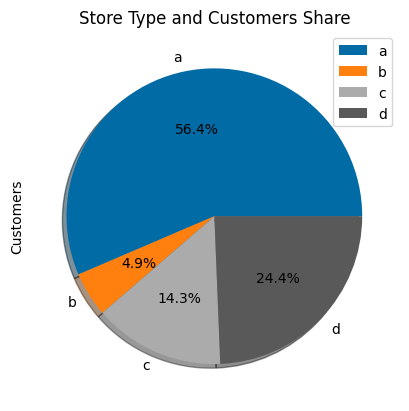

In [188]:
final_df.groupby('StoreType')['Customers'].sum().plot.pie(title='Store Type and Customers Share', legend=True, autopct='%1.1f%%', shadow=True)
plt.show()

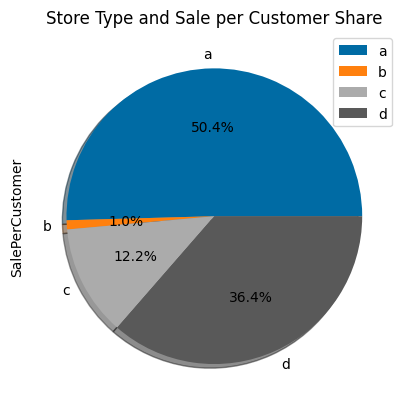

In [189]:
final_df.groupby('StoreType')['SalePerCustomer'].sum().plot.pie(title='Store Type and Sale per Customer Share', legend=True, autopct='%1.1f%%', shadow=True)
plt.show()

The three above are related and almost show the same thing.

The below chart shows the proportion of the store types (already discernible in the above barchart)

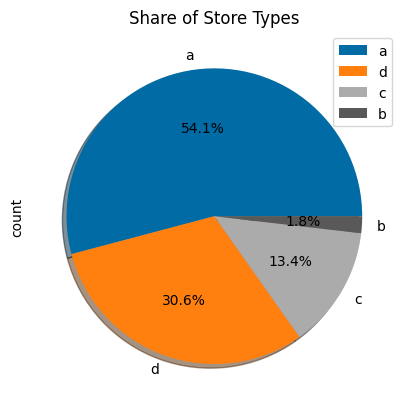

In [190]:
final_df['StoreType'].value_counts().plot.pie(title='Share of Store Types', legend=True, autopct='%1.1f%%', shadow=True)
plt.show()

A pie chart is a suitable way for summarising a set of nominal data or displaying the different values of a given variable.

- The majority of the stores are physical stores.
- There is a small percentage of online stores.
- There is a small percentage of other types of stores.

Upon further exploration it can be observed that the highest sales belonged to the store type a due to the high number of type a stores in the data set. Stores type a and c had a similar kind of salesand customer share.

Store type b has the highest average sales, and a reason for that could be that all three kinds of assortment strategies are involved in that category.

These insights can be used to help the business in making the decision on where to open new stores considering the existing store types, and what products or services to offer.




## 5.4. Sales Trend, Seasonality (Oscillation), and Noise Patterns

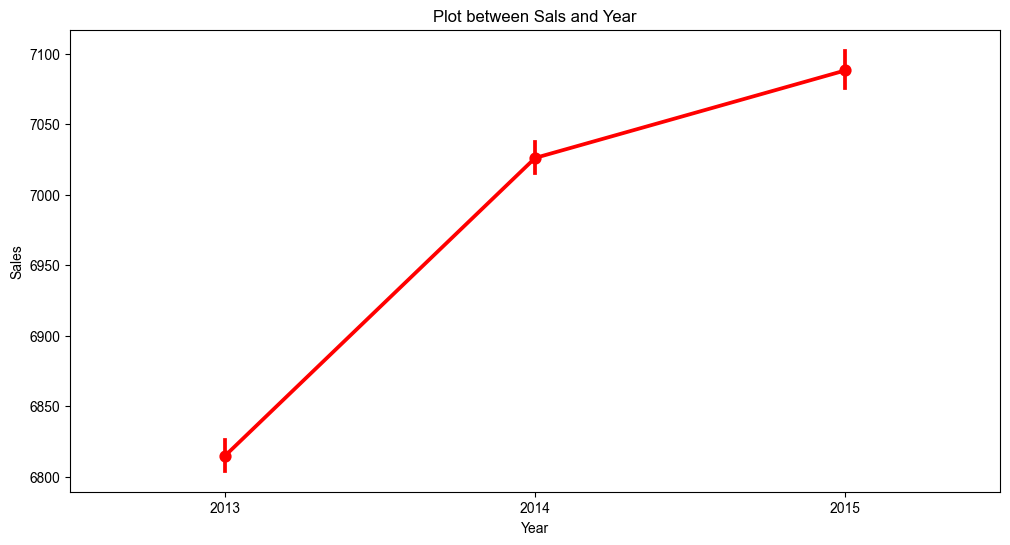

In [191]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='Year', y='Sales', data=final_df, color='red');
sns.set_style('dark')
plt.title('Plot between Sals and Year')
plt.show()

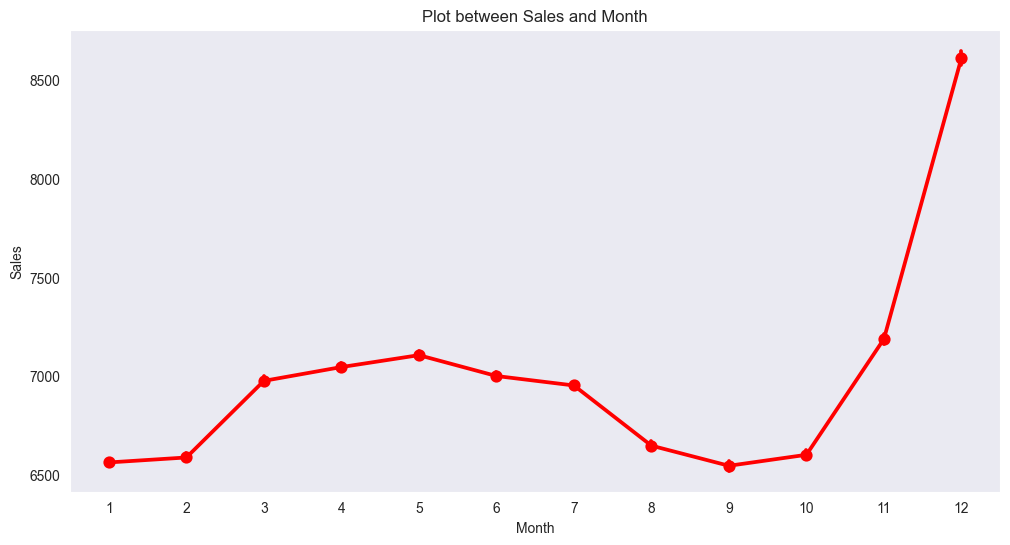

In [192]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='Month', y='Sales', data=final_df, color='red');
sns.set_style('dark')
plt.title('Plot between Sales and Month')
plt.show()

In [193]:
df = final_df.copy()
df.set_index('Date', inplace=True)

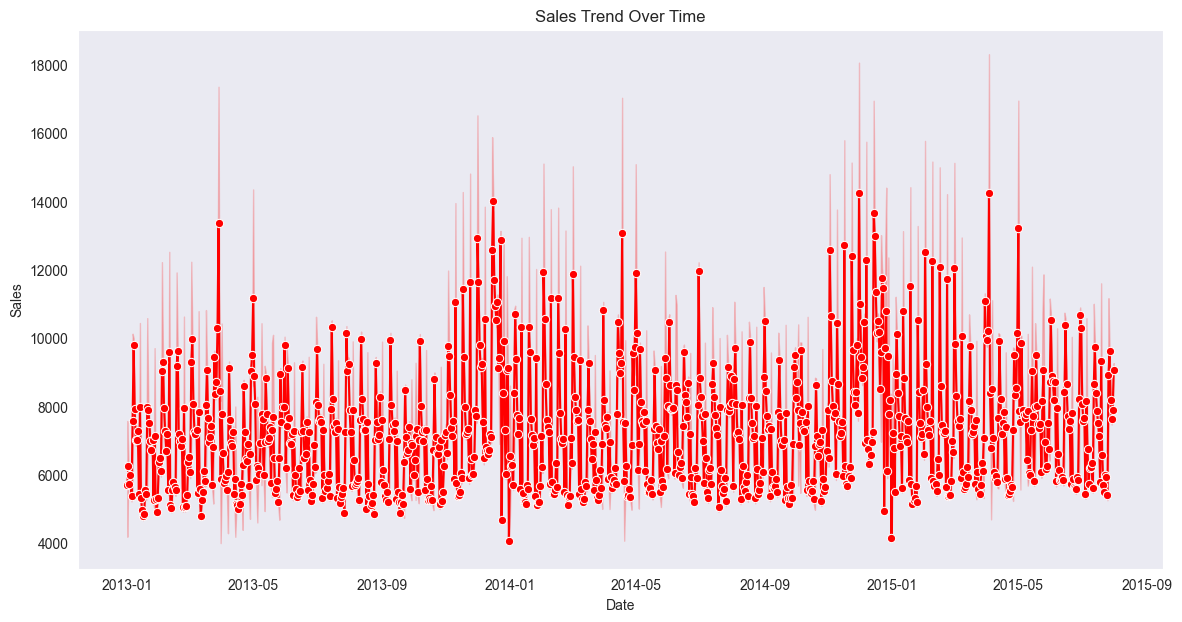

In [194]:
# Create the plot
plt.figure(figsize=(14, 7))
sns.lineplot(x=df.index, y='Sales', data=df, marker='o', color='red')

# Optional: Add a title and labels
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

# Show the plot
plt.show()

In [195]:
# Free memory
del df

We can see that sale increases in the months 3-7 and 11-12. 

This result coincides with the increase of sale in the Easter and Christmas holidays.

The important catch from these three charts is the existence of an increasing trend, oscillation, and noise. 
These should be taken into consideration if we want to use the auto-correlation in the data. 
Nevertheless, as the analysis shows, we can model the sale and customers with an event-driven approach, and avoid the costly (at evaluation time) nonparametric auto-correlation methods.

## 5.5 Physical vs Online Sales trend

In [196]:
final_df.StoreType.unique()

array(['c', 'a', 'b', 'd'], dtype=object)

In [197]:
total_physical = final_df.loc[(final_df['StoreType']=='a') | (final_df['StoreType']=='c'), ['Year','Sales']]

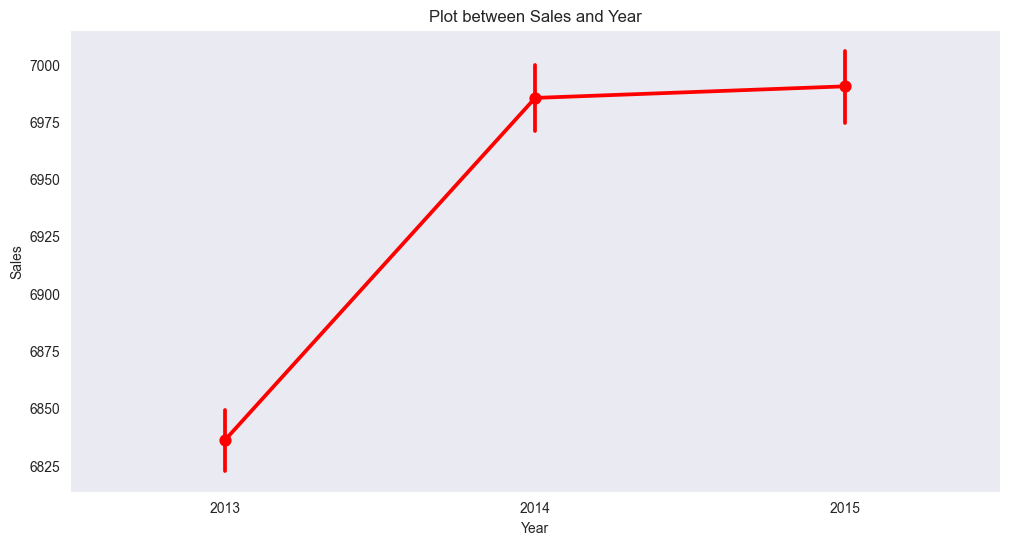

In [198]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='Year', y='Sales', data=total_physical, color='red');
sns.set_style('dark')
plt.title('Plot between Sales and Year')
plt.show()

In [199]:
total_online = final_df.loc[(final_df['StoreType']=='d'), ['Year','Sales']]

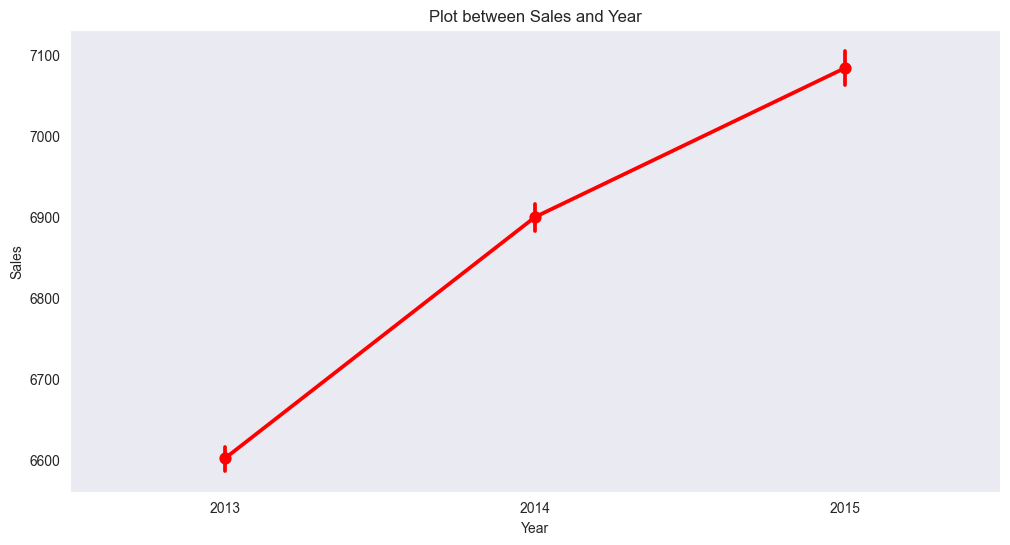

In [200]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='Year', y='Sales', data=total_online, color='red');
sns.set_style('dark')
plt.title('Plot between Sales and Year')
plt.show()

We observe that the status of sales for physical stores becomes steady, and for online shops, growing. If this trend continues, considering the heavy dependence of the business on physical stores, it might fall behind in the competition with its rivals.

## 5.6. Cutomers v.s. Sales and Independence of SalePerCustomer

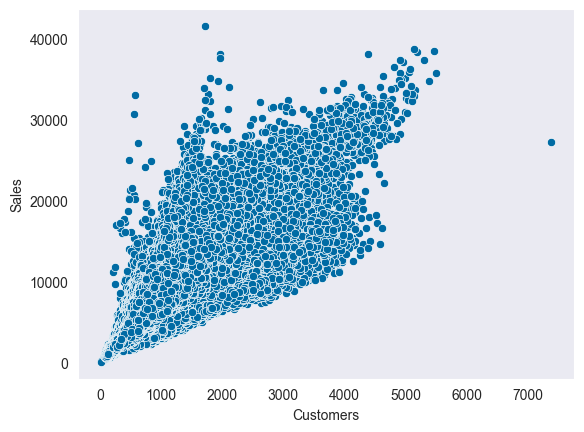

In [201]:
sns.scatterplot(x=final_df['Customers'], y=final_df['Sales']);

We can see a high positive correlation (linear relationship) between sales and customers. 
This can also be discovered in the correlation heatmap.

Since they are highly correlated, whatever conclusion that we make about 'Sales' it would also be valid for 'Customers'.

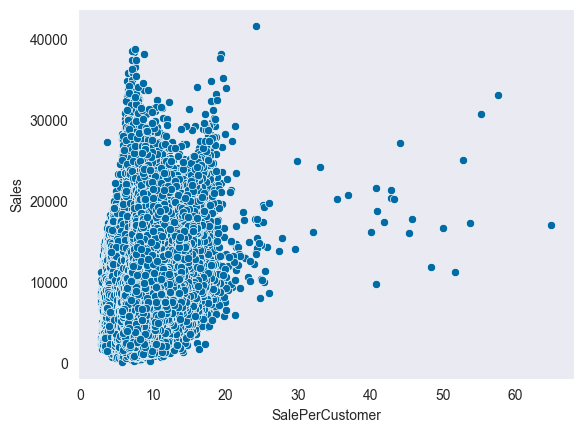

In [202]:
sns.scatterplot(x=final_df['SalePerCustomer'], y=final_df['Sales']);

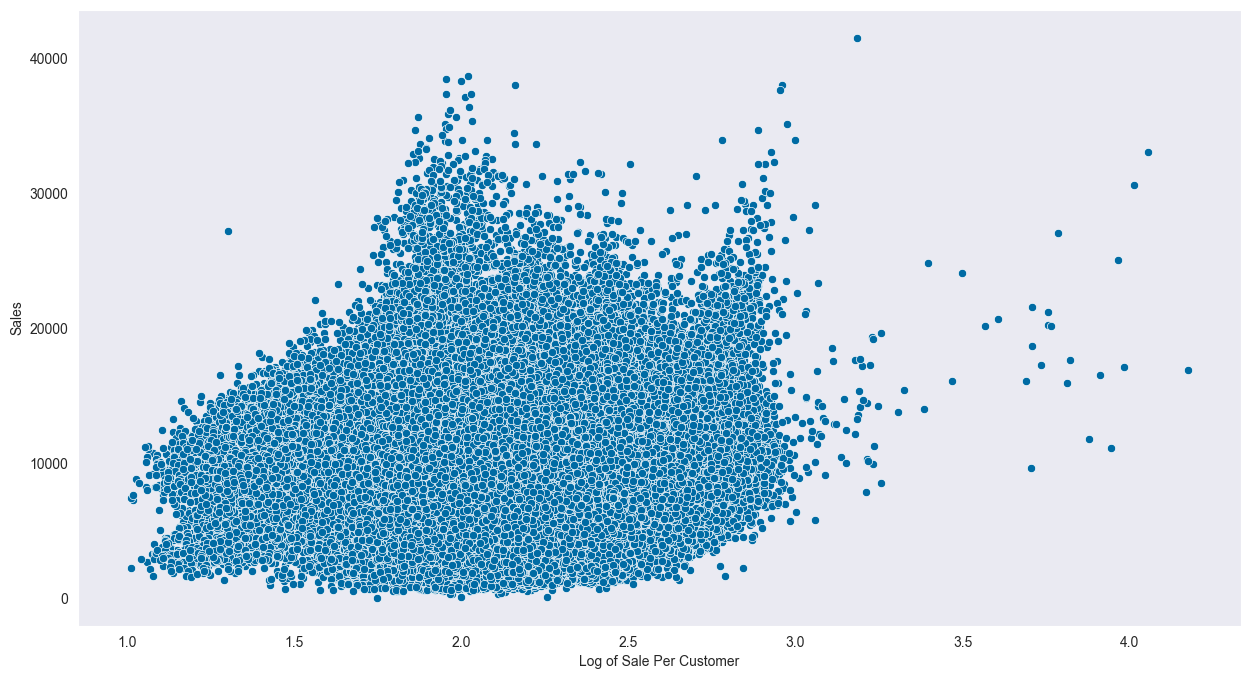

In [203]:
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(x=np.log(final_df['SalePerCustomer']), y=final_df['Sales'])

# Add x-axis label
ax.set_xlabel('Log of Sale Per Customer')

# Add y-axis label (optional, if you want to set it as well)
ax.set_ylabel('Sales')

plt.show()

We see that Sales becomes almost linearly independent from sale per customer. This can be conformed by the correlation heatmap in 5.10.

## 5.7. Effect of Competition Distance on Sales

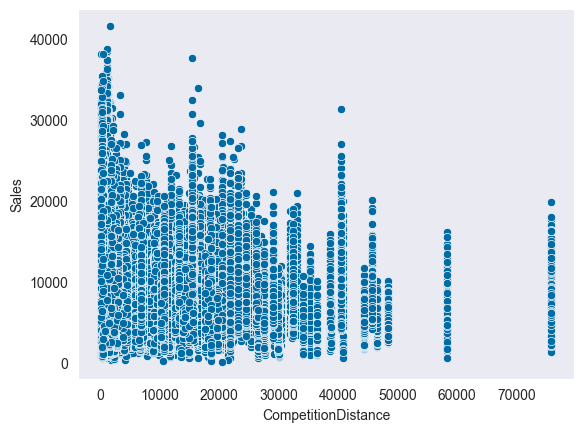

In [204]:
sns.scatterplot(x=final_df.CompetitionDistance, y=final_df.Sales);

Although the competition distance increases, the sale doesn't increase, this could be due to the highly populated regions

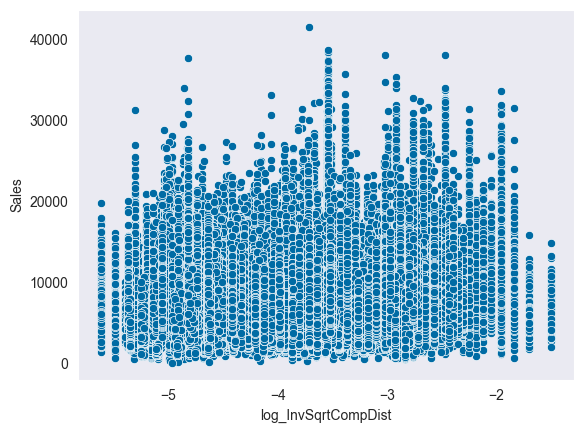

In [205]:
sns.scatterplot(x=final_df.log_InvSqrtCompDist, y=final_df.Sales);

Nothing useful can be found by this chart.

## 5.8. Temperature vs Sale

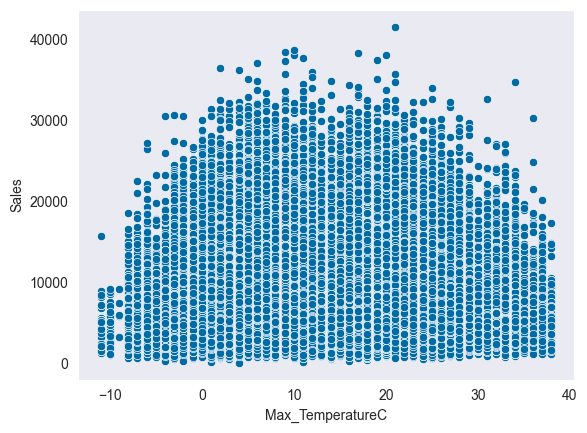

In [206]:
sns.scatterplot(x=final_df.Max_TemperatureC, y=final_df.Sales);

Not much can be understood by this scatter plots.

## 5.9. Humidity vs Sale

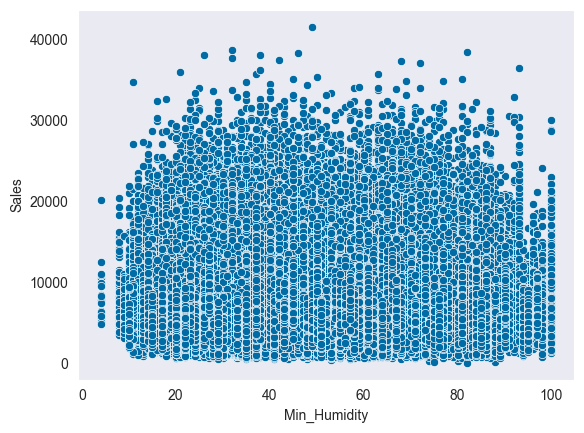

In [207]:
sns.scatterplot(x=final_df.Min_Humidity, y=final_df.Sales);

Not much can be understood by this scatter plots.

## 5.10. Correlation

To be able to perform correlation analysis we need to convert the 'bool' variables to 'int8'

In [208]:
temp_df = final_df.copy()

In [209]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DayOfWeek            844338 non-null  int64         
 1   Date                 844338 non-null  datetime64[ns]
 2   Sales                844338 non-null  int32         
 3   Customers            844338 non-null  int16         
 4   Promo                844338 non-null  bool          
 5   StateHoliday         844338 non-null  object        
 6   SchoolHoliday        844338 non-null  bool          
 7   SalePerCustomer      844338 non-null  float64       
 8   Year                 844338 non-null  int32         
 9   Month                844338 non-null  int32         
 10  StoreType            844338 non-null  object        
 11  Assortment           844338 non-null  int8          
 12  CompetitionDistance  844338 non-null  int32         
 13  Promo2        

In [210]:
final_df = final_df.astype(
    {
        'Promo': 'int8', 
        'Promo2': 'int8', 
        'SchoolHoliday': 'int8', 
    }
)

In [211]:
numeric_df = final_df.select_dtypes(include=['number'])
numeric_df.columns

Index(['DayOfWeek', 'Sales', 'Customers', 'Promo', 'SchoolHoliday',
       'SalePerCustomer', 'Year', 'Month', 'Assortment', 'CompetitionDistance',
       'Promo2', 'log_InvSqrtCompDist', 'Promo2Duration',
       'CompetitionDuration', 'Max_TemperatureC', 'Min_Humidity'],
      dtype='object')

In [212]:
excl_vars = [
    'StateHoliday',
    'StoreType',
    'Year', 
    'Month',
    'Store', 
    'CompetitionDistance', 
]

In [213]:
cols = [col for col in numeric_df.columns if col not in excl_vars]
cols

['DayOfWeek',
 'Sales',
 'Customers',
 'Promo',
 'SchoolHoliday',
 'SalePerCustomer',
 'Assortment',
 'Promo2',
 'log_InvSqrtCompDist',
 'Promo2Duration',
 'CompetitionDuration',
 'Max_TemperatureC',
 'Min_Humidity']

In [214]:
numeric_df = numeric_df[cols]

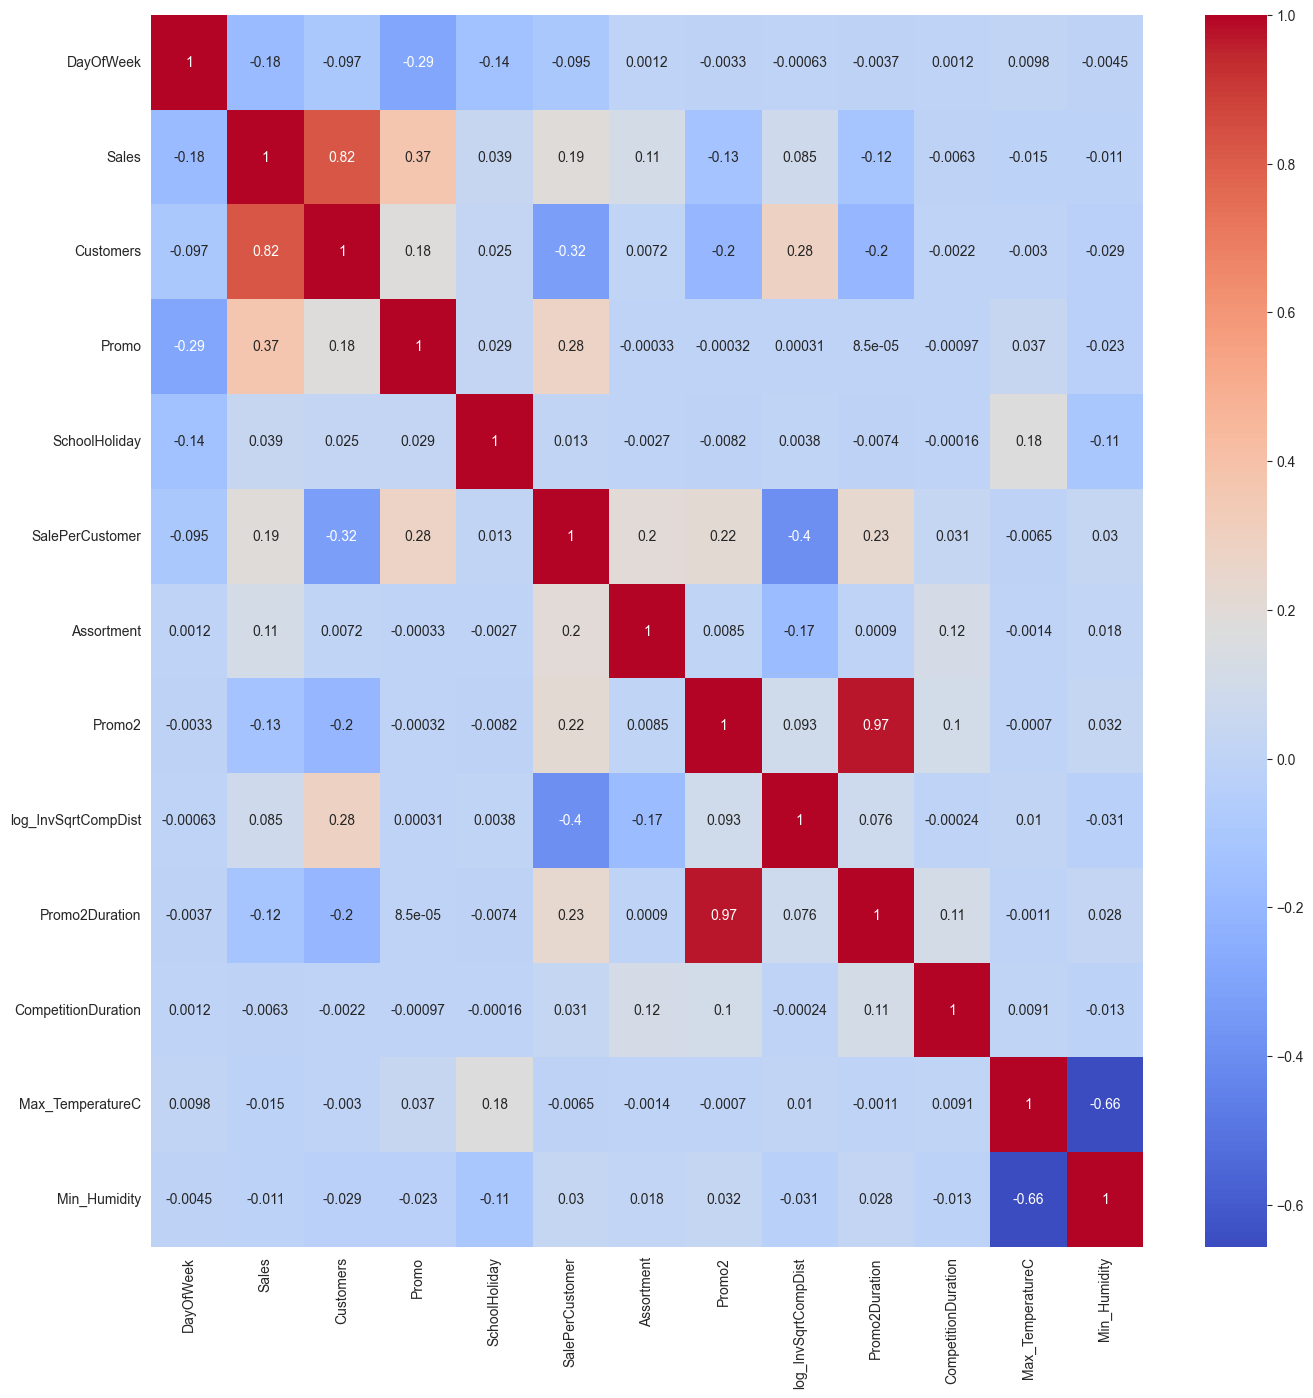

In [215]:
plt.figure(figsize=(16, 16))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True);

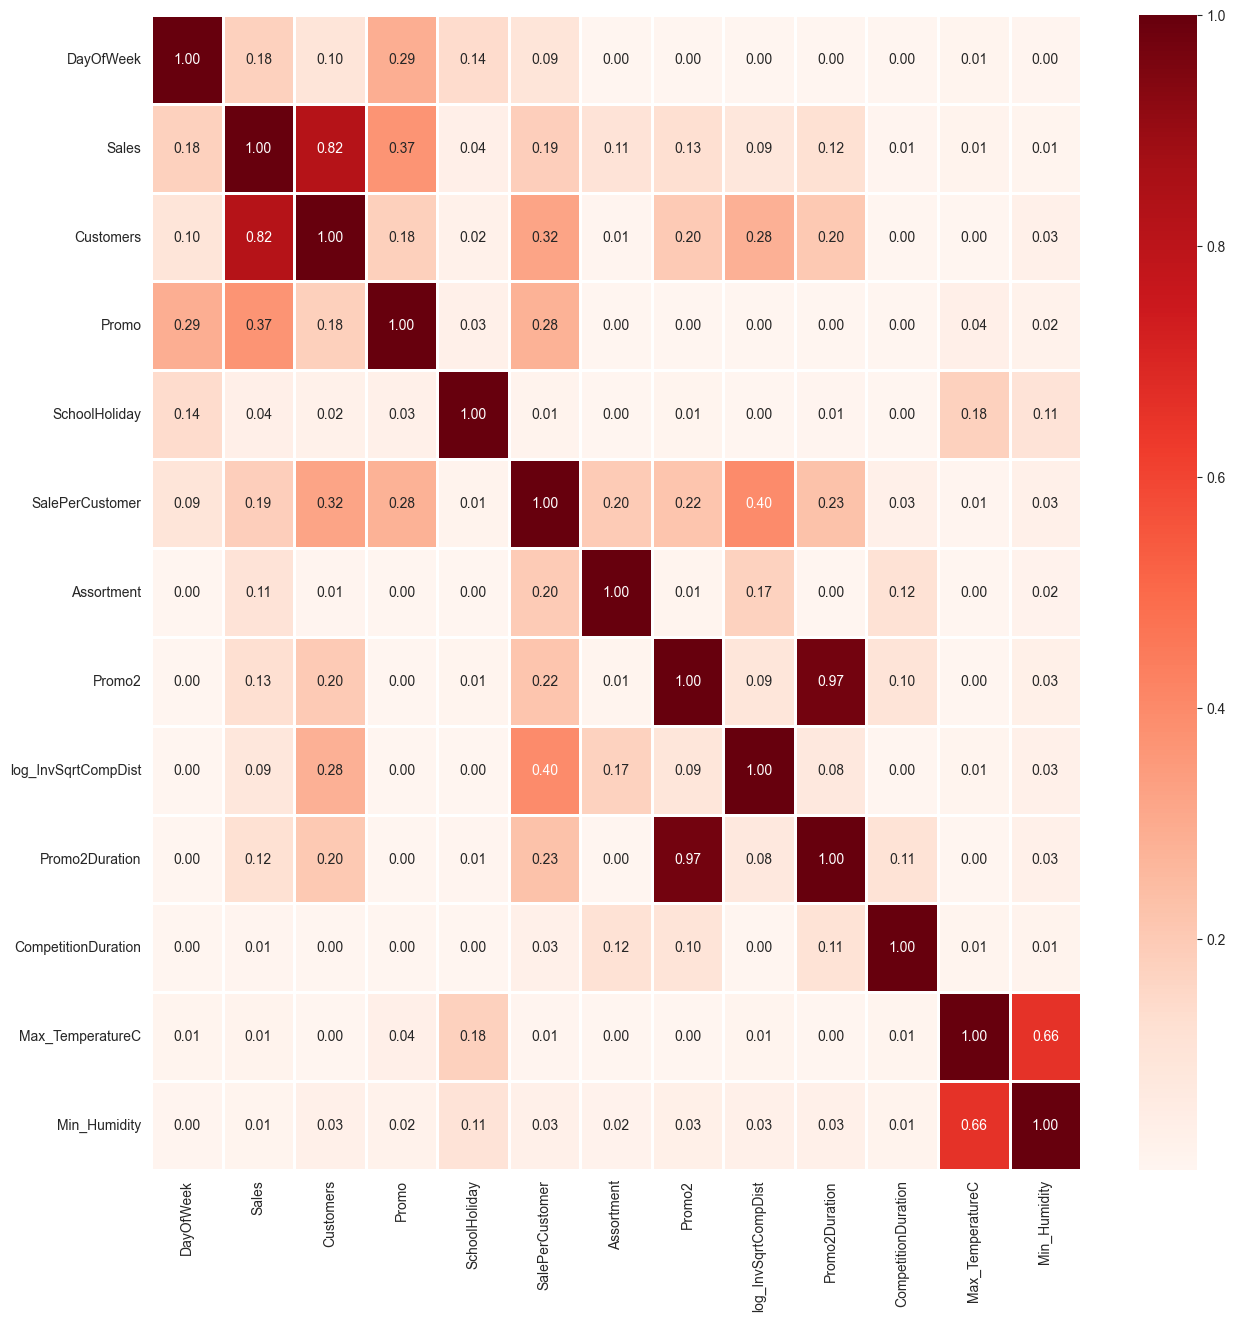

In [216]:
correlation = numeric_df.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(abs(correlation), annot=True, cmap='Reds', linewidths=2, fmt='.2f');

The following factors have the highest effect on SalePerCustomer:
1) Promo2Duration, which subsumes the availability of Promo2;
2) log_InvSqrtCompDist;
3) Assortment;
4) Promo;

Nevertheless, correlation analysis can't recognise the nonlinear relationships.

While we saw that there are some patterns that affect sales and customers, the factors identified by the correlation analysis are event-driven.

# 6. Prediction

We are conisdering separate regression models for 'Sales' and 'Customers'. 

## 6.0. Initialisation

### 6.0.1. Defining Different Inputs and Outputs & Checking Multicollinearity

Talk about the the importance of avoiding multicollinearity.

The variance inflation factor is a measure for the increase of the variance of the parameter estimates if an additional variable is added to the linear regression. It is a measure for multicollinearity of the design matrix.

One recommendation is that if VIF is greater than 5, then the explanatory variable is highly collinear with the other explanatory variables, and the parameter estimates will have large standard errors because of this.

In [217]:
def calc_vif(X):
    vif = pd.DataFrame()
    vif['variables'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)

In [218]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DayOfWeek            844338 non-null  int64         
 1   Date                 844338 non-null  datetime64[ns]
 2   Sales                844338 non-null  int32         
 3   Customers            844338 non-null  int16         
 4   Promo                844338 non-null  int8          
 5   StateHoliday         844338 non-null  object        
 6   SchoolHoliday        844338 non-null  int8          
 7   SalePerCustomer      844338 non-null  float64       
 8   Year                 844338 non-null  int32         
 9   Month                844338 non-null  int32         
 10  StoreType            844338 non-null  object        
 11  Assortment           844338 non-null  int8          
 12  CompetitionDistance  844338 non-null  int32         
 13  Promo2        

In [219]:
numeric_df = final_df.select_dtypes(include=['number'])

In [220]:
numeric_df.columns

Index(['DayOfWeek', 'Sales', 'Customers', 'Promo', 'SchoolHoliday',
       'SalePerCustomer', 'Year', 'Month', 'Assortment', 'CompetitionDistance',
       'Promo2', 'log_InvSqrtCompDist', 'Promo2Duration',
       'CompetitionDuration', 'Max_TemperatureC', 'Min_Humidity'],
      dtype='object')

In [221]:
numeric_df.drop(['Sales', 'Customers', 'SalePerCustomer', 'CompetitionDistance'], axis=1, inplace=True)

In [222]:
calc_vif(numeric_df)

,variables,VIF
0,DayOfWeek,5.766953
1,Promo,1.977007
2,SchoolHoliday,1.313455
3,Year,58.551478
4,Month,5.124331
5,Assortment,1.981701
6,Promo2,39.211819
7,log_InvSqrtCompDist,26.161544
8,Promo2Duration,38.119067
9,CompetitionDuration,1.914286


In [223]:
df1 = numeric_df.drop(['Promo2', 'Year'], axis=1)

In [224]:
calc_vif(df1)

,variables,VIF
0,DayOfWeek,5.200679
1,Promo,1.903219
2,SchoolHoliday,1.307804
3,Month,5.116195
4,Assortment,1.976145
5,log_InvSqrtCompDist,15.812156
6,Promo2Duration,1.947080
7,CompetitionDuration,1.890177
8,Max_TemperatureC,6.351865
9,Min_Humidity,9.883023


In [225]:
df2 = df1.drop(['Min_Humidity'], axis=1)

In [226]:
calc_vif(df2)

,variables,VIF
0,DayOfWeek,4.877884
1,Promo,1.857757
2,SchoolHoliday,1.306583
3,Month,4.273224
4,Assortment,1.975908
5,log_InvSqrtCompDist,9.797460
6,Promo2Duration,1.894756
7,CompetitionDuration,1.884026
8,Max_TemperatureC,4.202232


In [227]:
df2.columns

Index(['DayOfWeek', 'Promo', 'SchoolHoliday', 'Month', 'Assortment',
       'log_InvSqrtCompDist', 'Promo2Duration', 'CompetitionDuration',
       'Max_TemperatureC'],
      dtype='object')

This final set of variables seem good for incorporating in linear regression.

It has to be noted that this has nothing to do with the provided test data set.

In [228]:
# Defining the dependent variables 1 & 2
dependent_variables_1 = ['Sales', 'Customers'] 
dependent_variables_2 = ['SalePerCustomer']

In [229]:
# Defining the independent variables 1
independent_variables_1 = list(df2.columns)
independent_variables_1

['DayOfWeek',
 'Promo',
 'SchoolHoliday',
 'Month',
 'Assortment',
 'log_InvSqrtCompDist',
 'Promo2Duration',
 'CompetitionDuration',
 'Max_TemperatureC']

In [252]:
# By setting 'Date' as index, it won't be included in the columns.
final_df.set_index('Date', inplace=True)
final_df.head()

,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,SalePerCustomer,Year,Month,StoreType,Assortment,CompetitionDistance,Promo2,PromoInterval,log_InvSqrtCompDist,Promo2Duration,CompetitionDuration,State,Max_TemperatureC,Min_Humidity
Date,,,,,,,,,,,,,,,,,,,,
2015-07-31,5,13995,1498,True,0,True,9.342457,2015,7,c,2,620,False,NaN,-3.214860,0,147,BE,19.0,30.0
2015-07-31,5,11144,1162,True,0,True,9.590361,2015,7,c,0,2240,False,NaN,-3.857115,0,147,BE,19.0,30.0
2015-07-31,5,6670,665,True,0,True,10.030075,2015,7,a,0,540,False,NaN,-3.145785,0,126,BE,19.0,30.0
2015-07-31,5,7791,971,True,0,True,8.023687,2015,7,b,0,1870,False,NaN,-3.766847,0,122,BE,19.0,30.0
2015-07-31,5,6379,715,True,0,True,8.921678,2015,7,a,0,560,False,NaN,-3.163968,0,132,BE,19.0,30.0


In [255]:
# By setting 'Date' as index, it won't be included in the columns.
new_total_df.set_index('Date', inplace=True)
new_total_df.head()

,Sales,Customers,Promo,SchoolHoliday,SalePerCustomer,Year,Assortment,CompetitionDistance,Promo2,log_InvSqrtCompDist,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-31,13995,1498,True,True,9.342457,2015,2,620,False,-3.214860,...,False,False,False,False,True,False,False,False,False,False
2015-07-31,11144,1162,True,True,9.590361,2015,0,2240,False,-3.857115,...,False,False,False,False,True,False,False,False,False,False
2015-07-31,6670,665,True,True,10.030075,2015,0,540,False,-3.145785,...,False,False,False,False,True,False,False,False,False,False
2015-07-31,7791,971,True,True,8.023687,2015,0,1870,False,-3.766847,...,False,False,False,False,True,False,False,False,False,False
2015-07-31,6379,715,True,True,8.921678,2015,0,560,False,-3.163968,...,False,False,False,False,True,False,False,False,False,False


In [256]:
# Defining the independent variables 2
# In this case we have to be careful to indicate the categorical variables in patsy.
independent_variables_2 = list(new_total_df.columns.drop(dependent_variables_1 + dependent_variables_2))
independent_variables_2

['Promo',
 'SchoolHoliday',
 'Year',
 'Assortment',
 'CompetitionDistance',
 'Promo2',
 'log_InvSqrtCompDist',
 'Promo2Duration',
 'CompetitionDuration',
 'Max_TemperatureC',
 'Min_Humidity',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'State_BE',
 'State_BW',
 'State_BY',
 'State_HB,NI',
 'State_HE',
 'State_HH',
 'State_NW',
 'State_RP',
 'State_SH',
 'State_SN',
 'State_ST',
 'State_TH',
 'StateHoliday_State_0_BE',
 'StateHoliday_State_0_BW',
 'StateHoliday_State_0_BY',
 'StateHoliday_State_0_HB,NI',
 'StateHoliday_State_0_HE',
 'StateHoliday_State_0_HH',
 'StateHoliday_State_0_NW',
 'StateHoliday_State_0_RP',
 'StateHoliday_State_0_SH',
 'StateHoliday_State_0_SN',
 'StateHoliday_State_0_ST',
 'StateHoliday_State_0_TH',
 'StateHoliday_State_a_BE',
 'StateHoliday_State_a_BW',
 'StateHoliday_State_a_BY',
 'StateHoliday_State_a_HB,NI',
 'StateHoliday_State_a_HE',
 'StateHoliday_State_a_HH',
 'StateHoliday_State_a_NW',
 'StateHoliday_State_a_RP',
 'State

### 6.0.2. Cross-Validation: Separating Train, Test (Validation) Sets

Considering separate train and test sets is essential to ensure that a machine learning model can generalize well to unseen data, thereby providing an unbiased evaluation of its performance. Without this separation, a model might overfit to the training data, leading to overly optimistic performance metrics that do not reflect its true predictive capability.

Leave-one-out cross-validation (LOOCV) is a technique where each data point in the dataset is used once as a test set while the remaining data points form the training set, which helps in assessing model performance with high precision but can be computationally expensive. Cross-validation, particularly k-fold cross-validation, involves splitting the dataset into k subsets and using each subset as a test set while the remaining k-1 subsets form the training set, providing a robust estimate of model performance by averaging the results across all k trials.

In [234]:
def train_test_vars(independent_variables: list, dependent_variables: list ,df: pd.DataFrame=final_df, test_portion=0.2):
    # This is not a Pandas data frame. This is a numpy array.
    X = df[independent_variables].values
    Y = df[dependent_variables].values
    
    # We do this for choosing the best model, since we don't have the values of the regressands for the test data.
    # Although this kind of data splitting is not suitable if we want to test the prediction power for models that use auto-correlation.
    # In the case of auto-correlation, a portion from the end of the data set should be considered as the test set.
    return train_test_split(X, Y, test_size=test_portion, random_state=0)

In [235]:
# Testing the function.
X_train, X_test, Y_train, Y_test = train_test_vars(independent_variables_1, dependent_variables_1)

In [236]:
def eval_model():
    score = model.score(X_train, Y_train)
    MSE = mse(Y_test, Y_pred)
    RMSE = np.sqrt(MSE)
    r2 = r2_score(Y_test, Y_pred)

    print(f'{score = }')
    print(f'{MSE = }')
    print(f'{RMSE = }')
    print(f'{r2 = }')

    # return pd.DataFrame(zip(Y_test, Y_pred), columns=['Actual', 'Prediction'])

## 6.1. (Generalised) Linear Regression

For modeling categorical variables (and interaction effects), we can directly use patsy in the linear regression model.

### 6.1.1. Linear Regression 1

In [258]:
X_train, X_test, Y_train, Y_test = train_test_vars(independent_variables_1, dependent_variables_2)

In [259]:
model = LinearRegression()

In [260]:
model.fit(X_train, Y_train)

LinearRegression()

In [261]:
Y_pred = model.predict(X_test)

In [262]:
eval_model()

score = 0.321961977672092
MSE = 3.2589992525418467
RMSE = 1.8052698558780198
r2 = 0.3225886536226187


In [263]:
model.coef_

array([[-1.58018202e-02,  1.22714194e+00,  4.41877390e-02,
         1.83517552e-02,  2.93356299e-01, -1.10883927e+00,
         2.20407388e-03, -5.10864958e-05, -5.57072419e-03]])

In [264]:
model.intercept_

array([3.924065])

### 6.1.2. Linear Regression 2

In [265]:
independent_variables_2

['Promo',
 'SchoolHoliday',
 'Year',
 'Assortment',
 'CompetitionDistance',
 'Promo2',
 'log_InvSqrtCompDist',
 'Promo2Duration',
 'CompetitionDuration',
 'Max_TemperatureC',
 'Min_Humidity',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'State_BE',
 'State_BW',
 'State_BY',
 'State_HB,NI',
 'State_HE',
 'State_HH',
 'State_NW',
 'State_RP',
 'State_SH',
 'State_SN',
 'State_ST',
 'State_TH',
 'StateHoliday_State_0_BE',
 'StateHoliday_State_0_BW',
 'StateHoliday_State_0_BY',
 'StateHoliday_State_0_HB,NI',
 'StateHoliday_State_0_HE',
 'StateHoliday_State_0_HH',
 'StateHoliday_State_0_NW',
 'StateHoliday_State_0_RP',
 'StateHoliday_State_0_SH',
 'StateHoliday_State_0_SN',
 'StateHoliday_State_0_ST',
 'StateHoliday_State_0_TH',
 'StateHoliday_State_a_BE',
 'StateHoliday_State_a_BW',
 'StateHoliday_State_a_BY',
 'StateHoliday_State_a_HB,NI',
 'StateHoliday_State_a_HE',
 'StateHoliday_State_a_HH',
 'StateHoliday_State_a_NW',
 'StateHoliday_State_a_RP',
 'State

In [266]:
X_train, X_test, Y_train, Y_test = train_test_vars(independent_variables_2, dependent_variables_2, df=new_total_df)

In [267]:
model = LinearRegression()

In [268]:
model.fit(X_train, Y_train)

LinearRegression()

In [269]:
Y_pred = model.predict(X_test)

In [270]:
eval_model()

score = 0.5932607748226083
MSE = 1.9561739093966553
RMSE = 1.3986328715558831
r2 = 0.5933922351534267


In [271]:
model.coef_

array([[ 1.36255336e+00,  1.67387003e-01,  2.45144545e-01,
         2.40334040e-01, -2.33730075e-05, -3.17104977e-01,
        -1.02033129e+00,  2.54142937e-03, -1.20697980e-04,
        -1.32164526e-02,  1.49648432e-03, -1.71874396e-01,
        -1.76464834e-01, -6.59245117e-02,  4.14263741e-01,
         1.16576607e+00, -1.34898731e-01,  3.57026315e-01,
         3.46339557e-01,  4.45056532e-01,  9.25830314e-01,
         1.62986073e-01, -5.40031017e-02, -1.42438843e+00,
        -1.62542622e-01, -1.05307081e+00, -5.74101160e-01,
        -8.42824528e-01,  4.88859511e-01,  6.39969465e-01,
        -9.10280230e-01,  3.03615709e-01, -1.89291719e+00,
         3.99061691e-02,  2.88332437e-01,  7.91600124e-01,
        -4.98836936e-02,  7.32841917e-01,  2.38905910e-01,
         1.12173391e+00, -1.31742136e-01, -2.27576482e-01,
         6.96137208e-01,  1.86808565e-02,  1.18077559e+00,
         3.98853280e-02, -1.05982370e-01, -5.67980120e-02,
        -1.12658929e-01, -1.78591273e+00, -8.13007070e-0

In [272]:
model.intercept_

array([-490.06401858])

All the coefficients are almost in the same range, not too large and not too small. Therefore, we can expect the ridge method to also provide similar results, and the model have a low variance in cross-validation.

## 6.1. (Generalised) Linear Regression (cont.)

In [273]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [274]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, Y_train)

LinearRegression()

In [275]:
V_pred = linear_regression.predict(X_test)
V_pred

array([[ 8.42824268],
       [10.62471485],
       [ 9.12379932],
       ...,
       [10.22829151],
       [12.49562549],
       [ 7.1654253 ]])

In [277]:
linear_regression.score(X_train, Y_train)

0.593237566739962

In [276]:
regression_DataFrame = pd.DataFrame(zip(Y_test, Y_pred), columns=['Actual', 'Prediction'])
regression_DataFrame

,Actual,Prediction
0,[8.693498452012383],[8.423761678271376]
1,[11.74410480349345],[10.626293550645642]
2,[9.53623188405797],[9.117927679450759]
3,[6.729216152019003],[8.522870602403884]
4,[10.16810344827586],[9.985039750120507]
...,...,...
168863,[6.995522388059701],[8.276607903643367]
168864,[9.82099596231494],[11.542477214182327]
168865,[10.9623786407767],[10.227205438633746]
168866,[12.862790697674418],[12.496499030025177]


In [282]:
eval_model()

score = -51638.64334324601
MSE = 1.9561739093966553
RMSE = 1.3986328715558831
r2 = 0.5933922351534267


## 6.2. LASSO

In [283]:
L1 = Lasso(alpha=0.4, max_iter=10000, selection='cyclic', tol=0.0001)

In [284]:
L1.fit(X_train, Y_train)

Lasso(alpha=0.4, max_iter=10000)

In [285]:
Y_pred_lasso = L1.predict(X_test)

In [286]:
L1.score(X_test, Y_test)

0.3746105308595904

In [288]:
cv_scores = cross_val_score(L1, X_train, Y_train, cv=10)
mean_cv_score = cv_scores.mean()

In [289]:
cv_scores

array([0.37639922, 0.37847972, 0.37877114, 0.37473452, 0.36930035,
       0.37639546, 0.37594796, 0.37022275, 0.3778562 , 0.37480747])

In [290]:
mean_cv_score

0.3752914794857337

In [291]:
# Define the range of alpha values
parameters = {'alpha': [0.1, 0.2, 0.3, 0.4, 0.5]}

In [292]:
lasso_cv = GridSearchCV(L1, parameters, cv=5)
lasso_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=Lasso(alpha=0.4, max_iter=10000),
             param_grid={'alpha': [0.1, 0.2, 0.3, 0.4, 0.5]})

In [293]:
best_alpha_lasso = lasso_cv.best_params_['alpha']
best_score_lasso = lasso_cv.best_score_

In [294]:
best_alpha_lasso

0.1

In [295]:
best_score_lasso

0.5431331421728969

In [297]:
pd.DataFrame(zip(Y_test, Y_pred_lasso), columns=['Actual', 'Prediction'])

,Actual,Prediction
0,[8.693498452012383],8.925210
1,[11.74410480349345],9.706693
2,[9.53623188405797],8.927943
3,[6.729216152019003],8.731511
4,[10.16810344827586],9.118410
...,...,...
168863,[6.995522388059701],8.914022
168864,[9.82099596231494],10.997252
168865,[10.9623786407767],9.698234
168866,[12.862790697674418],11.089024


In [298]:
L2 = Ridge(alpha=0.5)

In [299]:
L2.fit(X_train, Y_train)

Ridge(alpha=0.5)

In [300]:
L2.predict(X_test)

array([[ 8.42376115],
       [10.62628701],
       [ 9.11792568],
       ...,
       [10.22719939],
       [12.49649612],
       [ 7.15275072]])

In [301]:
L2.score(X_test, Y_test)

0.5933922350358165

## 6.3. Ridge

In [302]:
ridge = Ridge(max_iter=10000, solver='auto')

In [303]:
parameters = {'alpha': [0.1, 0.2, 0.3, 0.4, 0.5]}

In [304]:
ridge_cv = GridSearchCV(L2, parameters, cv=5)
ridge_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=Ridge(alpha=0.5),
             param_grid={'alpha': [0.1, 0.2, 0.3, 0.4, 0.5]})

In [305]:
best_alpha = ridge_cv.best_params_['alpha']
best_score = ridge_cv.best_score_

In [306]:
ridge_best = Ridge(alpha=best_alpha, max_iter=10000, solver='auto')
cv_scores = cross_val_score(ridge_best, X_train, Y_train, cv=5)

In [307]:
max_score = cv_scores.max()

In [310]:
print(f'{best_alpha = }')
print(f'{best_score = }')
print(f'{max_score = }')

best_alpha = 0.5
best_score = 0.5931942088199398
max_score = 0.5962718503733638


Keeping best_score, when trying different models

## 6.4. Elastic Net

In [311]:
elastic_net = ElasticNet(max_iter=10000)

In [312]:
parameters = {'alpha': [0.1, 0.2, 0.3, 0.4, 0.5], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

In [313]:
elastic_net_cv = GridSearchCV(elastic_net, parameters, cv=5)
elastic_net_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=10000),
             param_grid={'alpha': [0.1, 0.2, 0.3, 0.4, 0.5],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]})

In [314]:
best_alpha = elastic_net_cv.best_params_['alpha']
best_l1_ratio = elastic_net_cv.best_params_['l1_ratio']
best_score_elastic = elastic_net_cv.best_score_

In [316]:
# Create an Elastic Net model with the best hyperparameters
elastic_net_best = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000)
elastic_net_best.fit(X_train, Y_train)

ElasticNet(alpha=0.1, l1_ratio=0.1, max_iter=10000)

In [317]:
test_score = elastic_net_best.score(X_test, Y_test)

In [318]:
print(f'{best_alpha = }')
print(f'{best_l1_ratio = }')
print(f'{best_score = }')
print(f'{test_score = }')

best_alpha = 0.1
best_l1_ratio = 0.1
best_score = 0.5931942088199398
test_score = 0.5847087173686343


## 6.5. Decision Tree

In [324]:
decision_tree = DecisionTreeRegressor(max_depth=5)
decision_tree.fit(X_train, Y_train)
Y_pred_DT = decision_tree.predict(X_test)
Y_train_DT = decision_tree.predict(X_train)

In [325]:
R2 = r2_score(Y_test, Y_pred_DT)
print(f'{R2 = }')

R2 = 0.5576326807274778


In [326]:
MSE = mse(Y_test, Y_pred_DT)
RMSE = np.sqrt(MSE)
print(f'{MSE = }')
print(f'{RMSE = }')

MSE = 2.128211714444687
RMSE = 1.4588391667502922


In [327]:
decision_tree_DataFrame = pd.DataFrame(zip(Y_test, Y_pred_DT), columns=['Actual', 'Prediction'])
decision_tree_DataFrame

,Actual,Prediction
0,[8.693498452012383],8.526171
1,[11.74410480349345],12.222683
2,[9.53623188405797],8.526171
3,[6.729216152019003],8.029220
4,[10.16810344827586],10.622635
...,...,...
168863,[6.995522388059701],8.526171
168864,[9.82099596231494],11.187413
168865,[10.9623786407767],12.222683
168866,[12.862790697674418],13.035106


## 6.6. Random Forest Regression

In [328]:
# Create a random forest regressor
random_forest = RandomForestRegressor(n_estimators=500, max_depth=8, n_jobs=2)

In [331]:
Y_train.shape

(675470, 1)

In [333]:
# Fit the random forest to the training data
random_forest.fit(X_train, Y_train.ravel())

RandomForestRegressor(max_depth=8, n_estimators=500, n_jobs=2)

In [334]:
Y_pred_RF = random_forest.predict(X_test)

In [335]:
MSE = mse(Y_test, Y_pred_RF)
RMSE = np.sqrt(MSE)

print(f'{MSE = }')
print(f'{RMSE = }')

MSE = 1.6012518842052323
RMSE = 1.2654058179909053


In [336]:
R2 = r2_score(Y_test, Y_pred_RF)
print(f'{R2 = }')

R2 = 0.6671658657415243


## 6.7. Adaboost

In [338]:
adaboost = AdaBoostRegressor(n_estimators=500, learning_rate=0.01)
adaboost.fit(X_train, Y_train.ravel())

AdaBoostRegressor(learning_rate=0.01, n_estimators=500)

In [339]:
Y_pred_ada = adaboost.predict(X_test)

In [340]:
MSE = mse(Y_test, Y_pred_ada)
RMSE = np.sqrt(MSE)

print(f'{MSE = }')
print(f'{RMSE = }')

MSE = 2.6749670028288817
RMSE = 1.63553263581895


In [341]:
R2 = r2_score(Y_test, Y_pred_ada)
print(f'{R2 = }')

R2 = 0.44398483752701823


## 6.8. XGBoost

In [343]:
xgboost = xgb.XGBRegressor(max_depth=9, n_jobs=2)
xgboost.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=2,
             num_parallel_tree=None, random_state=None, ...)

In [344]:
Y_pred_xgb = xgboost.predict(X_test)

In [345]:
MSE = mse(Y_test, Y_pred_xgb)
RMSE = np.sqrt(MSE)

print(f'{MSE = }')
print(f'{RMSE = }')

MSE = 0.32296082706954526
RMSE = 0.5682964253534816


In [346]:
R2 = r2_score(Y_test, Y_pred_xgb)
print(f'{R2 = }')

R2 = 0.9328697824886892


## 6.9. LSTM

In [347]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.optimizers import Adam
import matplotlib.pyplot as plt


In [352]:
%pwd

'C:\\Drive D\\Python\\Rossmann\\datasets'

In [355]:
# Load the data
data = pd.read_csv(r'train_df.csv', parse_dates=['Date'], low_memory=False)
data.sort_values('Date', inplace=True)

# Select the relevant features
features = ['Store', 'DayOfWeek', 'Sales', 'Customers', 'Promo', 'StateHoliday', 'SchoolHoliday']

# Preprocess the data
data['StateHoliday'] = data['StateHoliday'].astype('category').cat.codes
data['Store'] = data['Store'].astype('category').cat.codes

# Scale the features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Prepare the training data
def create_dataset(data, time_step=1):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        a = data[i:(i+time_step), :-2]
        X.append(a)
        Y.append(data[i + time_step, -2:])
    return np.array(X), np.array(Y)

time_step = 60  # Number of previous days to consider for prediction
data_values = data[features].values

X, Y = create_dataset(data_values, time_step)

# Split into training and test sets
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(Y)]


Epoch 1/5
10554/10554 ━━━━━━━━━━━━━━━━━━━━ 341s 32ms/step - loss: 0.0755 - val_loss: 0.0692
Epoch 2/5
10554/10554 ━━━━━━━━━━━━━━━━━━━━ 341s 32ms/step - loss: 0.0743 - val_loss: 0.0667
Epoch 3/5
10554/10554 ━━━━━━━━━━━━━━━━━━━━ 342s 32ms/step - loss: 0.0735 - val_loss: 0.0667
Epoch 4/5
10554/10554 ━━━━━━━━━━━━━━━━━━━━ 352s 33ms/step - loss: 0.0719 - val_loss: 0.0656
Epoch 5/5
10554/10554 ━━━━━━━━━━━━━━━━━━━━ 349s 33ms/step - loss: 0.0716 - val_loss: 0.0681


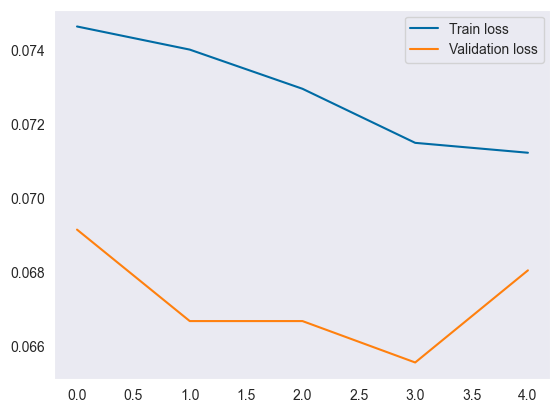

In [362]:
# Define the input layer
input_layer = Input(shape=(time_step, X_train.shape[2]))

# Add the LSTM and Dense layers
x = LSTM(50, return_sequences=True)(input_layer)
x = LSTM(50, return_sequences=False)(x)
x = Dense(25)(x)
output_layer = Dense(2)(x)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
history = model.fit(X_train, Y_train, epochs=5, batch_size=64, validation_data=(X_test, Y_test), verbose=1)

# Plot the training and validation loss
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()


In [363]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform the predictions
train_predict = scaler.inverse_transform(np.hstack((train_predict, np.zeros((train_predict.shape[0], data_values.shape[1] - 2)))))
test_predict = scaler.inverse_transform(np.hstack((test_predict, np.zeros((test_predict.shape[0], data_values.shape[1] - 2)))))
Y_train_inverse = scaler.inverse_transform(np.hstack((Y_train, np.zeros((Y_train.shape[0], data_values.shape[1] - 2)))))
Y_test_inverse = scaler.inverse_transform(np.hstack((Y_test, np.zeros((Y_test.shape[0], data_values.shape[1] - 2)))))

# Calculate RMSE
train_rmse = np.sqrt(np.mean((train_predict[:, :2] - Y_train_inverse[:, :2])**2, axis=0))
test_rmse = np.sqrt(np.mean((test_predict[:, :2] - Y_test_inverse[:, :2])**2, axis=0))

print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')


21107/21107 ━━━━━━━━━━━━━━━━━━━━ 163s 8ms/step
5277/5277 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step
Train RMSE: [15.39124441  2.26019048]
Test RMSE: [14.96598038  2.21217256]


pitfalls:
- interpretability

# 7. Conclusion and Future research

## 7.1. Results

- The 'Sales' column contained 172817 rows with 0 sale. Therefore, I created a new data frame in which the 0 sale rows were removed.
- Different models were tried (although we could also try omptimizing the parameters of the models using BO)
- If we include the 0 sales data set we would obtain a far better performance in methods such decision tree, random forest, adaboost, xgboost, and this is because there would be the obviously correct solution of sale being 0 when the store is closed!
- The best accuracy is obtained from the ?? model (after optimization of the prameters/ hyperparameters)
- 

## 7.2. Future Research

- Considering the v-structure, it is better to exploit the dependence of the outputs and use multi-tasking. In this respect considering the:
    - Trend (increasing/ decreasing)
    - Seasonality (Oscillation)
    - Random noise

    we can apply Gaussian processes.

- The other idea would be to extract the causal structure. Having a causal graphical model, we can integrate out the effect of the variables that we don't have. We can also introduce more structure in terms of latent variables.

-  